# Dog Breed Training Experiments

This notebook is the laboratory for the dissertation:
*Training and Evaluation of a 10-Breed Dog Breed Classifier Using Imagewoof*.

It mirrors the dissertation report sections and is designed to:

- establish a reproducible environment and configuration (Section 1 / Section 3)
- load and explore the Imagewoof dataset (Section 3)
- train and compare transfer-learning models (Section 4 / Section 5)
- generate all tables and figures cited in the report (Section 4 / Section 5)
- run a secondary evaluation on the curated `external_images` set (Section 4.3)

Run cells **top-to-bottom** in a clean kernel for a fully reproducible execution.


## 1. Experiment Design

Mirrors the system architecture described in **Section 1** of the dissertation report.

- **Main dataset:** Imagewoof (10 dog-breed classes, class-per-directory layout)
- **Split strategy:** `train/` split 80/20 for training and internal validation; `val/` used as held-out test set
- **Architectures:** MobileNetV2, EfficientNetB0 (ResNet50 excluded from final analysis)
- **Training strategies:** feature extraction (head-only), then selective fine-tuning
- **Secondary evaluation:** selected models evaluated on the 20-image `external_images` set (Section 4.3)
- **No augmentation:** intentionally omitted to isolate the effect of architecture and training strategy


## 2. Setup and Reproducibility

The cells below establish the environment, set all configuration constants, and initialise
random seeds so that all experiments produce deterministic results on the same hardware.

**Run these cells first** before any training or evaluation.

Expected outputs:
- TensorFlow version, Python executable, and platform printed
- GPU detected and configured for TensorFlow, or a clear error if the notebook is running from a CPU-only kernel
- All required paths confirmed as existing
- Seeds initialised


In [4]:
from pathlib import Path
import platform
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("Python executable:", sys.executable)
print("Platform:", platform.platform())
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TensorFlow version: 2.21.0
Python executable: c:\ProgramData\anaconda3\python.exe
Platform: Windows-11-10.0.26200-SP0


### Configuration Constants

All experiment parameters are defined here so we don't have scattered constants across other cells.

| Constant | Value | Rationale |
|---|---|---|
| `IMAGE_SIZE` | `(224, 224)` | Required input size for MobileNetV2 and EfficientNetB0 |
| `BATCH_SIZE` | `16` | Standard batch size |
| `SEED` | `42` | Fixed seed for deterministic split and weight initialisation |
| `TRAIN_VAL_SPLIT` | `0.2` | 80/20 split from `train/`; `val/` folder is the held-out test set |
| `HEAD_EPOCHS` | `100` | Maximum epoch cap for head-only training; early stopping (patience=`ES_PATIENCE_HEAD`) controls the actual count |
| `FINE_TUNE_EPOCHS` | `100` | Maximum epoch cap for fine-tuning phase; early stopping (patience=`ES_PATIENCE_FINE_TUNE`) controls the actual count |
| `ES_MONITOR` | `val_loss` | Metric monitored by EarlyStopping callbacks |
| `ES_PATIENCE_HEAD` | `10` | Epochs without improvement before stopping head-only training |
| `ES_PATIENCE_FINE_TUNE` | `7` | Epochs without improvement before stopping fine-tuning |
| `ES_MIN_DELTA` | `1e-4` | Minimum change in monitored metric to qualify as improvement |
| `HEAD_LEARNING_RATE` | `1e-3` | Standard Adam rate for head-only training |
| `FINE_TUNE_LEARNING_RATE` | `1e-5` | Low rate to avoid destroying pre-trained weights during fine-tuning |
| `FINE_TUNE_LAYERS` | `30` | Number of top base-model layers unfrozen during fine-tuning |
| `REQUIRE_GPU` | `True` | Block training unless this notebook is attached to a GPU-enabled TensorFlow kernel |
| `ENABLE_MIXED_PRECISION` | `True` | Use mixed precision automatically when the active GPU backend supports it well; native Windows DirectML falls back to float32 |
| `CACHE_DATASETS_TO_DISK` | `False` | Keep caching explicit instead of silently filling RAM during training |


In [5]:
# Set PROJECT_ROOT_OVERRIDE only if you run this notebook outside the repository root.
PROJECT_ROOT_OVERRIDE = None
PROJECT_ROOT = (
    Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    if PROJECT_ROOT_OVERRIDE
    else Path.cwd()
)
IMAGEWOOF_ROOT = PROJECT_ROOT / "imagewoof"
TRAIN_DIR = IMAGEWOOF_ROOT / "train"
TEST_DIR = IMAGEWOOF_ROOT / "val"
EXTERNAL_DIR = PROJECT_ROOT / "external_images"
EXTERNAL_MANIFEST = PROJECT_ROOT / "external_images_manifest.csv"
RESULTS_DIR = PROJECT_ROOT / "results"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
TRAIN_VAL_SPLIT = 0.2
HEAD_EPOCHS = 100
FINE_TUNE_EPOCHS = 100
HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 30

REQUIRE_GPU = True
ENABLE_MIXED_PRECISION = True
CACHE_DATASETS_TO_DISK = False
DATASET_CACHE_DIR = RESULTS_DIR / "_dataset_cache"

ES_MONITOR = "val_loss"
ES_PATIENCE_HEAD = 10
ES_PATIENCE_FINE_TUNE = 7
ES_MIN_DELTA = 1e-4

LABEL_MAP = {
    "n02086240": "Shih-Tzu",
    "n02087394": "Rhodesian Ridgeback",
    "n02088364": "Beagle",
    "n02089973": "English Foxhound",
    "n02093754": "Australian Terrier",
    "n02096294": "Border Terrier",
    "n02099601": "Golden Retriever",
    "n02105641": "Old English Sheepdog",
    "n02111889": "Samoyed",
    "n02115641": "Dingo",
}

MODEL_CONFIGS = {
    "MobileNetV2": {
        "constructor": keras.applications.MobileNetV2,
        "preprocess": keras.applications.mobilenet_v2.preprocess_input,
    },
    "EfficientNetB0": {
        "constructor": keras.applications.EfficientNetB0,
        "preprocess": keras.applications.efficientnet.preprocess_input,
    },
    "ResNet50": {
        "constructor": keras.applications.ResNet50,
        "preprocess": keras.applications.resnet50.preprocess_input,
    },
}

RESULTS_DIR.mkdir(exist_ok=True)

for path in [PROJECT_ROOT, EXTERNAL_DIR, EXTERNAL_MANIFEST, RESULTS_DIR]:
    print(path, "exists ->", path.exists())

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        "Imagewoof dataset not found. Place it under "
        f"{IMAGEWOOF_ROOT} with train/ and val/ folders, run prepare_imagewoof_dataset.py, "
        "or update IMAGEWOOF_ROOT in this cell."
    )

e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation exists -> True
e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\external_images exists -> True
e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\external_images_manifest.csv exists -> True
e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results exists -> True


In [49]:
def running_in_wsl() -> bool:
    uname = platform.uname()
    release = getattr(uname, "release", "").lower()
    version = getattr(uname, "version", "").lower()
    return "microsoft" in release or "wsl" in version

def configure_tensorflow_runtime(
    require_gpu: bool = REQUIRE_GPU,
    enable_mixed_precision: bool = ENABLE_MIXED_PRECISION,
):
    # Initialise random state before any dataset loading or model construction.
    random.seed(SEED)
    np.random.seed(SEED)
    keras.utils.set_random_seed(SEED)

    try:
        tf.config.experimental.enable_op_determinism()
        print("Deterministic ops enabled.")
    except Exception as ex:
        print(f"Deterministic ops not available on this platform: {ex}")

    build_info = tf.sysconfig.get_build_info()
    print("TensorFlow CUDA build:", build_info.get("is_cuda_build", False))
    if platform.system() == "Windows" and not running_in_wsl():
        print("Windows GPU note: use Python 3.10 + tensorflow-cpu==2.10 + tensorflow-directml-plugin for native GPU training.")

    use_mixed_precision = enable_mixed_precision and not (platform.system() == "Windows" and not running_in_wsl())

    gpu_devices = tf.config.list_physical_devices("GPU")
    if gpu_devices:
        for gpu in gpu_devices:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as ex:
                print(f"Could not enable memory growth for {gpu.name}: {ex}")

        print("Physical GPU devices:", [gpu.name for gpu in gpu_devices])

        if use_mixed_precision:
            keras.mixed_precision.set_global_policy("mixed_float16")
            print("Mixed precision policy:", keras.mixed_precision.global_policy())
        else:
            keras.mixed_precision.set_global_policy("float32")
            if enable_mixed_precision and platform.system() == "Windows" and not running_in_wsl():
                print("Mixed precision disabled on native Windows DirectML to keep training on the stable float32 path.")
            else:
                print("Mixed precision disabled.")
    else:
        keras.mixed_precision.set_global_policy("float32")

        if require_gpu:
            if platform.system() == "Windows" and not running_in_wsl():
                raise RuntimeError(
                    "No TensorFlow GPU device detected. Native Windows TensorFlow needs the DirectML path for GPU training. "
                    "Create a Python 3.10 environment with tensorflow-cpu==2.10 and tensorflow-directml-plugin, "
                    "select that kernel in Jupyter, and restart the notebook before training."
                )

            raise RuntimeError(
                "No TensorFlow GPU device detected. Start Jupyter from a GPU-enabled TensorFlow environment before running the training cells."
            )

        print("GPU not detected. Continuing on CPU because REQUIRE_GPU=False.")

    print(f"Seeds initialised. SEED={SEED}")
    return gpu_devices


GPU_DEVICES = configure_tensorflow_runtime()
LOGICAL_GPU_DEVICES = tf.config.list_logical_devices("GPU")
print("Logical GPU devices:", [device.name for device in LOGICAL_GPU_DEVICES])

Deterministic ops enabled.
TensorFlow CUDA build: False
Windows GPU note: use Python 3.10 + tensorflow-cpu==2.10 + tensorflow-directml-plugin for native GPU training.
Could not enable memory growth for /physical_device:GPU:0: Physical devices cannot be modified after being initialized
Physical GPU devices: ['/physical_device:GPU:0']
Mixed precision disabled on native Windows DirectML to keep training on the stable float32 path.
Seeds initialised. SEED=42
Logical GPU devices: ['/device:GPU:0']


## 3. Data Loading and Exploration

Mirrors **Section 3** of the dissertation report (dataset description and split strategy).

**Split strategy:**
- `imagewoof/train/` is split 80/20 using `keras.utils.image_dataset_from_directory` with a fixed `seed=42`.  
  The 80 % partition forms the **training set**; the 20 % partition is the **internal validation set**.
- `imagewoof/val/` is used as the **held-out test set** — it is never seen during training or validation.

**Class mapping:** folder names (WordNet IDs) are translated to human-readable breed names via `LABEL_MAP`.

Expected outputs after the loading cell:
- `train_ds`, `val_ds`, `test_ds` TensorFlow datasets ready and prefetched
- 10 class names printed


In [50]:
AUTOTUNE = tf.data.AUTOTUNE

def prepare_dataset(dataset, cache_name: str):
    if CACHE_DATASETS_TO_DISK:
        DATASET_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        dataset = dataset.cache(str(DATASET_CACHE_DIR / cache_name))
    return dataset.prefetch(AUTOTUNE)


train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=TRAIN_VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=TRAIN_VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_ids = train_ds.class_names
class_names = [LABEL_MAP.get(class_id, class_id) for class_id in class_ids]
num_classes = len(class_names)

train_ds = prepare_dataset(train_ds, "train")
val_ds = prepare_dataset(val_ds, "validation")
test_ds = prepare_dataset(test_ds, "test")

print("Class IDs:", class_ids)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 9025 files belonging to 10 classes.
Using 7220 files for training.
Found 9025 files belonging to 10 classes.
Using 1805 files for validation.
Found 3929 files belonging to 10 classes.
Class IDs: ['n02086240', 'n02087394', 'n02088364', 'n02089973', 'n02093754', 'n02096294', 'n02099601', 'n02105641', 'n02111889', 'n02115641']
Classes: ['Shih-Tzu', 'Rhodesian Ridgeback', 'Beagle', 'English Foxhound', 'Australian Terrier', 'Border Terrier', 'Golden Retriever', 'Old English Sheepdog', 'Samoyed', 'Dingo']
Number of classes: 10


In [51]:
# --- Dataset size summary ---
# Count images per class per split by reading the directory structure on disk.
# This mirrors the dataset statistics described in Section 3 of the report.

def count_images_in_dir(directory: Path, label_map: dict) -> pd.DataFrame:
    rows = []
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            n = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in {'.jpg', '.jpeg', '.png'})
            rows.append({'class_id': class_dir.name, 'breed': label_map.get(class_dir.name, class_dir.name), 'count': n})
    return pd.DataFrame(rows)

train_full_counts = count_images_in_dir(TRAIN_DIR, LABEL_MAP)
test_counts = count_images_in_dir(TEST_DIR, LABEL_MAP)

train_split_counts = (train_full_counts[['breed', 'count']]
    .rename(columns={'count': 'train_dir_total'})
    .assign(
        train_80pct=lambda df: (df['train_dir_total'] * (1 - TRAIN_VAL_SPLIT)).round().astype(int),
        val_20pct=lambda df: (df['train_dir_total'] * TRAIN_VAL_SPLIT).round().astype(int),
    ))

dataset_summary = train_split_counts.merge(
    test_counts[['breed', 'count']].rename(columns={'count': 'test_held_out'}),
    on='breed',
)

print(f"Training split total  (~80%): {dataset_summary['train_80pct'].sum()} images")
print(f"Validation split total (~20%): {dataset_summary['val_20pct'].sum()} images")
print(f"Held-out test total:           {dataset_summary['test_held_out'].sum()} images")
print()
display(dataset_summary[['breed', 'train_80pct', 'val_20pct', 'test_held_out']])

Training split total  (~80%): 7220 images
Validation split total (~20%): 1805 images
Held-out test total:           3929 images



,breed,train_80pct,val_20pct,test_held_out
0,Shih-Tzu,753,188,409
1,Rhodesian Ridgeback,754,188,408
2,Beagle,746,186,418
3,English Foxhound,464,116,224
4,Australian Terrier,759,190,401
5,Border Terrier,754,189,407
6,Golden Retriever,759,190,401
7,Old English Sheepdog,742,186,422
8,Samoyed,737,184,429
9,Dingo,752,188,410


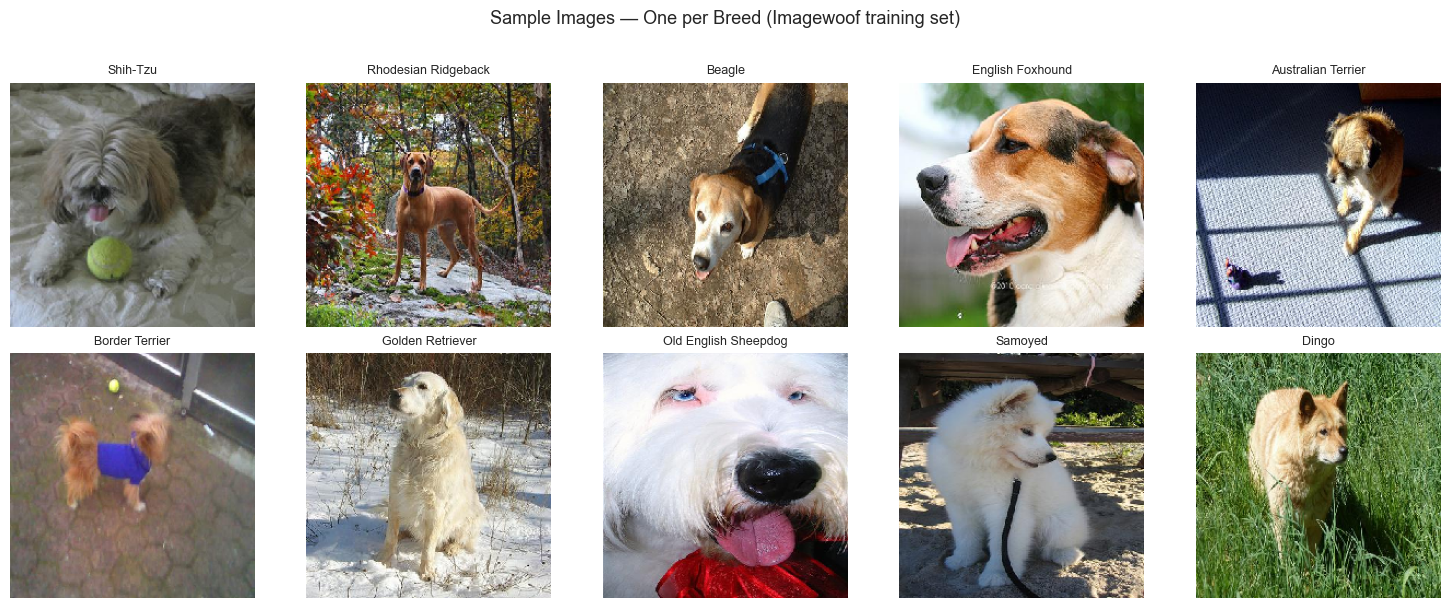

In [52]:
# --- Sample image grid ---
# Display one representative image per breed from the training directory.
# This confirms the dataset is readable and the class mapping is correct.

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images — One per Breed (Imagewoof training set)', fontsize=13, y=1.01)

for ax, class_id in zip(axes.flat, sorted(LABEL_MAP.keys())):
    class_dir = TRAIN_DIR / class_id
    # Pick the first image alphabetically for reproducibility
    image_path = sorted(class_dir.iterdir())[0]
    img = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    ax.imshow(img)
    ax.set_title(LABEL_MAP[class_id], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Dataset Integrity Check

The cell below verifies that all 10 breed classes are present in both the `train/` and `val/` directories and that no image files are zero-byte (i.e. unreadable). Run it once before training. If issues are flagged, restore the affected class folders before proceeding.


In [53]:
# For each class folder in train/ and val/, reports:
#   - how many image files are present
#   - how many are zero-byte (unreadable placeholder files)

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.JPEG', '.JPG'}
integrity_rows = []

for split_name, split_dir in [('train', TRAIN_DIR), ('val (test)', TEST_DIR)]:
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        breed = LABEL_MAP.get(class_dir.name, class_dir.name)
        files = [f for f in class_dir.iterdir() if f.suffix in VALID_EXTS]
        zero_byte = [f.name for f in files if f.stat().st_size == 0]
        integrity_rows.append({
            'split': split_name,
            'breed': breed,
            'file_count': len(files),
            'zero_byte_files': len(zero_byte),
        })

integrity_df = pd.DataFrame(integrity_rows)
issues = integrity_df[(integrity_df['file_count'] < 50) | (integrity_df['zero_byte_files'] > 0)]

if issues.empty:
    print("✓ No integrity issues found. All classes present with sufficient images.")
else:
    print(f"⚠  {len(issues)} class/split combination(s) with issues — review before training:")
    display(issues)

print("\nFull class counts:")
display(integrity_df[['split', 'breed', 'file_count', 'zero_byte_files']])

✓ No integrity issues found. All classes present with sufficient images.

Full class counts:


,split,breed,file_count,zero_byte_files
0,train,Shih-Tzu,941,0
1,train,Rhodesian Ridgeback,942,0
2,train,Beagle,932,0
3,train,English Foxhound,580,0
4,train,Australian Terrier,949,0
5,train,Border Terrier,943,0
6,train,Golden Retriever,949,0
7,train,Old English Sheepdog,928,0
8,train,Samoyed,921,0
9,train,Dingo,940,0


## 4. Helper Functions

The cell below defines all reusable functions used throughout this notebook. Run it once before any training or evaluation cell.

| Function | Purpose |
|---|---|
| `build_model(model_name)` | Constructs and compiles a transfer-learning model (frozen base + classification head) from `MODEL_CONFIGS` |
| `plot_history(history_df, title)` | Plots training vs. validation loss and accuracy curves from a history DataFrame |
| `collect_predictions(model, dataset)` | Runs inference over a dataset and returns `y_true`, `y_pred`, and `y_prob` arrays |
| `evaluate_model(model, dataset, labels)` | Wraps `collect_predictions` and computes a classification report and confusion matrix |
| `save_experiment_artifacts(results)` | Saves `history.csv`, `classification_report.csv`, `confusion_matrix.npy`, `model.keras`, and `training_curves.png` to `results/<run_name>/` |
| `summarize_experiments(experiment_results)` | Aggregates accuracy and F1 metrics from a list of experiment result dicts into a summary DataFrame |

> **Note:** `run_experiment()` (defined separately below) orchestrates these helpers for a full train-and-evaluate cycle.


In [54]:
# compile model with appropriate loss and metrics for multi-class classification
def compile_model(model, learning_rate: float):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

# build a transfer learning model with the specified base 
# architecture and preprocessing
def build_model(model_name: str):
    config = MODEL_CONFIGS[model_name]
    constructor = config["constructor"]
    preprocess_fn = config["preprocess"]

    inputs = keras.Input(shape=IMAGE_SIZE + (3,))
    x = keras.layers.Lambda(preprocess_fn, name="preprocess")(inputs)
    base_model = constructor(
        include_top=False,
        weights="imagenet",
        input_shape=IMAGE_SIZE + (3,),
    )
    base_model.trainable = False
    x = base_model(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions",
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)
    compile_model(model, HEAD_LEARNING_RATE)
    return model, base_model

# Plot training history curves for loss and accuracy.
def plot_history(history_df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title} - Loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title=f"{title} - Accuracy")
    plt.tight_layout()
    return fig

# Collect true labels, predicted labels, and predicted probabilities 
# from the model on the given dataset.
def collect_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset], axis=0)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

# Evaluate the model on the given dataset and return the classification report, 
# confusion matrix, and raw predictions.
def evaluate_model(model, dataset, labels):
    y_true, y_pred, y_prob = collect_predictions(model, dataset)
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred)
    return report, cm, y_true, y_pred, y_prob

# Save model, training history, classification report, 
# and confusion matrix to the results directory for this run.
def save_experiment_artifacts(results: dict):
    from keras.saving.saved_model import json_utils as _keras_json_utils

    run_name = results.get("run_name", results["model_name"])
    model_dir = RESULTS_DIR / run_name
    model_dir.mkdir(parents=True, exist_ok=True)
    results["history"].to_csv(model_dir / "history.csv", index=False)
    results["classification_report"].to_csv(model_dir / "classification_report.csv")
    np.save(model_dir / "confusion_matrix.npy", results["confusion_matrix"])

    # EfficientNetB0 stores its rescaling statistics as EagerTensors in the
    # model config. Keras's own json_utils.get_json_type handles np.ndarray
    # but not EagerTensor. Patch it temporarily before saving.
    _orig_get_json_type = _keras_json_utils.get_json_type

    def _eager_aware_get_json_type(obj):
        if hasattr(obj, "numpy"):
            return obj.numpy().tolist()
        return _orig_get_json_type(obj)

    _keras_json_utils.get_json_type = _eager_aware_get_json_type
    try:
        results["model"].save(model_dir / "model.keras")
    finally:
        _keras_json_utils.get_json_type = _orig_get_json_type

    fig = plot_history(results["history"], run_name)
    fig.savefig(model_dir / "training_curves.png", bbox_inches="tight")
    plt.close(fig)

# Summarize experiment results across multiple runs into 
# a single DataFrame and save to CSV.
def summarize_experiments(experiment_results):
    rows = []
    for result in experiment_results:
        report_df = result["classification_report"]
        rows.append(
            {
                "model_name": result["model_name"],
                "accuracy": report_df.loc["accuracy", "precision"],
                "macro_f1": report_df.loc["macro avg", "f1-score"],
                "weighted_f1": report_df.loc["weighted avg", "f1-score"],
            }
        )
    summary = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
    summary.to_csv(RESULTS_DIR / "experiment_summary.csv", index=False)
    return summary

# ** No expected output from this cell ** 

In [55]:
# For each run name, check that all expected artifacts are present 
# in the results directory and summarize in a DataFrame.
def sanity_checkpoint(run_names):
    rows = []
    for run_name in run_names:
        run_dir = RESULTS_DIR / run_name
        required = [
            'history.csv',
            'classification_report.csv',
            'confusion_matrix.npy',
            'model.keras',
            'training_curves.png',
        ]
        present = {f: (run_dir / f).exists() for f in required}
        rows.append({
            'run_name': run_name,
            'all_present': all(present.values()),
            **present,
        })
    return pd.DataFrame(rows)

# ** No expected output from this cell ** 

## Optional Quick Check

Use this only when you want to quickly verify that expected artifacts exist for selected runs.

Example command:
`display(sanity_checkpoint(['MobileNetV2_E3_HeadOnly', 'EfficientNetB0_E3_HeadOnly']))`

In [56]:
def ensure_training_runtime():
    logical_gpus = tf.config.list_logical_devices("GPU")
    if REQUIRE_GPU and not logical_gpus:
        raise RuntimeError(
            "Training is blocked because this Jupyter kernel does not expose a TensorFlow GPU. "
            "Reopen the notebook with the GPU-enabled kernel from the setup instructions, restart the kernel, and rerun the notebook top-to-bottom."
        )

    print("Training device(s):", [device.name for device in logical_gpus] or ["CPU"])
    print("Precision policy:", keras.mixed_precision.global_policy())
    return logical_gpus


def _history_to_df(keras_history):
    """Convert a Keras History object to a DataFrame, coercing EagerTensors to Python floats."""
    return pd.DataFrame({k: [float(v) for v in vals]
                         for k, vals in keras_history.history.items()})

def run_experiment(
    model_name: str,
    head_epochs: int = HEAD_EPOCHS,
    fine_tune_epochs: int = FINE_TUNE_EPOCHS,
    fine_tune_layers: int = FINE_TUNE_LAYERS,
    run_name: str | None = None,
):
    # Train a model and save all artifacts. Epoch counts are explicit to avoid global mutation.
    ensure_training_runtime()
    model, base_model = build_model(model_name)

    # Early stopping callbacks — separate instances so state resets cleanly between phases.
    es_head = keras.callbacks.EarlyStopping(
        monitor=ES_MONITOR,
        patience=ES_PATIENCE_HEAD,
        min_delta=ES_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )
    es_ft = keras.callbacks.EarlyStopping(
        monitor=ES_MONITOR,
        patience=ES_PATIENCE_FINE_TUNE,
        min_delta=ES_MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )

    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=head_epochs,
        callbacks=[es_head],
        verbose=1,
    )

    # Use actual epochs trained (may be less than head_epochs if early stopping fired).
    actual_head_epochs = len(history_head.epoch)
    history_frames = [_history_to_df(history_head)]

    if fine_tune_layers > 0 and fine_tune_epochs > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-fine_tune_layers]:
            layer.trainable = False

        compile_model(model, FINE_TUNE_LEARNING_RATE)

        history_ft = model.fit(
            train_ds,
            validation_data=val_ds,
            initial_epoch=actual_head_epochs,
            epochs=actual_head_epochs + fine_tune_epochs,
            callbacks=[es_ft],
            verbose=1,
        )
        history_frames.append(_history_to_df(history_ft))

    history_df = pd.concat(history_frames, ignore_index=True)
    report, cm, y_true, y_pred, y_prob = evaluate_model(model, test_ds, class_names)

    results = {
        "model_name": model_name,
        "run_name": run_name or model_name,
        "model": model,
        "history": history_df,
        "classification_report": pd.DataFrame(report).transpose(),
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }
    save_experiment_artifacts(results)
    return results

# ** No expected output from this cell ** 

## 5. Canonical Experiment Runs

These four cells reproduce the training runs cited in **Section 5.2 (Table 1)** of the dissertation report.
Run them **in order**, top to bottom.

Each cell includes an overwrite guard: if the run's `model.keras` already exists in `results/`, the cell skips training and prints a confirmation instead. Remove or rename the folder to force a re-run.

| Run | Strategy | Epochs (head) | Fine-tune epochs |
|---|---|---|---|
| `MobileNetV2` | Feature extraction only | 100 | — |
| `EfficientNetB0` | Feature extraction only | 100 | — |
| `MobileNetV2_FineTune` | Head-only then fine-tune | 100 | 100 |
| `EfficientNetB0_FineTune` | Head-only then fine-tune | 100 | 100 |


In [ ]:
# --- Run 1: MobileNetV2 (feature extraction only, early stopping up to 100 epochs) ---
# Corresponds to the MobileNetV2 baseline row in Report Table 1 (Section 5.2).

_run_name = 'MobileNetV2'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _model_path.exists():
    print(f"Skipping {_run_name}: artifacts already exist at {_model_path.parent}")
    print("Delete the folder and re-run this cell to retrain from scratch.")
else:
    mobilenet_results = run_experiment(
        model_name='MobileNetV2',
        head_epochs=HEAD_EPOCHS,
        fine_tune_epochs=0,
        fine_tune_layers=0,
        run_name=_run_name,
    )
    print(f"\n{_run_name} — summary metrics:")
    display(mobilenet_results['classification_report'].loc[
        ['accuracy', 'macro avg', 'weighted avg'],
        ['precision', 'recall', 'f1-score'],
    ])

Training device(s): ['/device:GPU:0']
Precision policy: <Policy "float32">
Epoch 1/100
452/452 [==============================] - 15s 30ms/step - loss: 0.3234 - accuracy: 0.9021 - val_loss: 0.1564 - val_accuracy: 0.9512
Epoch 2/100
452/452 [==============================] - 9s 20ms/step - loss: 0.1368 - accuracy: 0.9568 - val_loss: 0.1464 - val_accuracy: 0.9529
Epoch 3/100
452/452 [==============================] - 9s 20ms/step - loss: 0.1066 - accuracy: 0.9650 - val_loss: 0.1436 - val_accuracy: 0.9535
Epoch 4/100
452/452 [==============================] - 9s 20ms/step - loss: 0.0878 - accuracy: 0.9712 - val_loss: 0.1664 - val_accuracy: 0.9457
Epoch 5/100
452/452 [==============================] - 9s 21ms/step - loss: 0.0763 - accuracy: 0.9753 - val_loss: 0.1685 - val_accuracy: 0.9501
Epoch 6/100
452/452 [==============================] - 9s 21ms/step - loss: 0.0675 - accuracy: 0.9771 - val_loss: 0.1507 - val_accuracy: 0.9562
Epoch 7/100
452/452 [==============================] - 10s 2

,precision,recall,f1-score
accuracy,0.950878,0.950878,0.950878
macro avg,0.949505,0.946667,0.947636
weighted avg,0.951630,0.950878,0.950821


In [35]:
# --- Run 2: EfficientNetB0 (feature extraction only, early stopping up to 100 epochs) ---
# Corresponds to the EfficientNetB0 baseline row in Report Table 1 (Section 5.2).

_run_name = 'EfficientNetB0'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _model_path.exists():
    print(f"Skipping {_run_name}: artifacts already exist at {_model_path.parent}")
    print("Delete the folder and re-run this cell to retrain from scratch.")
else:
    efficientnet_results = run_experiment(
        model_name='EfficientNetB0',
        head_epochs=HEAD_EPOCHS,
        fine_tune_epochs=0,
        fine_tune_layers=0,
        run_name=_run_name,
    )
    print(f"\n{_run_name} — summary metrics:")
    display(efficientnet_results['classification_report'].loc[
        ['accuracy', 'macro avg', 'weighted avg'],
        ['precision', 'recall', 'f1-score'],
    ])


Training device(s): ['/device:GPU:0']
Precision policy: <Policy "float32">
Epoch 1/100
452/452 [==============================] - 19s 34ms/step - loss: 0.3218 - accuracy: 0.9183 - val_loss: 0.1356 - val_accuracy: 0.9651
Epoch 2/100
452/452 [==============================] - 14s 32ms/step - loss: 0.1286 - accuracy: 0.9605 - val_loss: 0.1179 - val_accuracy: 0.9684
Epoch 3/100
452/452 [==============================] - 14s 32ms/step - loss: 0.1034 - accuracy: 0.9675 - val_loss: 0.1134 - val_accuracy: 0.9657
Epoch 4/100
452/452 [==============================] - 15s 32ms/step - loss: 0.0852 - accuracy: 0.9748 - val_loss: 0.1124 - val_accuracy: 0.9668
Epoch 5/100
452/452 [==============================] - 14s 32ms/step - loss: 0.0764 - accuracy: 0.9756 - val_loss: 0.1101 - val_accuracy: 0.9668
Epoch 6/100
452/452 [==============================] - 14s 32ms/step - loss: 0.0677 - accuracy: 0.9784 - val_loss: 0.1111 - val_accuracy: 0.9662
Epoch 7/100
452/452 [==============================] - 

,precision,recall,f1-score
accuracy,0.957750,0.957750,0.957750
macro avg,0.954308,0.951845,0.952862
weighted avg,0.957749,0.957750,0.957569


In [36]:
# --- Run 3: MobileNetV2_FineTune (head-only then fine-tune, early stopping up to 100 epochs each) ---
# Corresponds to the MobileNetV2_FineTune row in Report Table 1 (Section 5.2).

_run_name = 'MobileNetV2_FineTune'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _model_path.exists():
    print(f"Skipping {_run_name}: artifacts already exist at {_model_path.parent}")
    print("Delete the folder and re-run this cell to retrain from scratch.")
else:
    mobilenet_finetune_results = run_experiment(
        model_name='MobileNetV2',
        head_epochs=HEAD_EPOCHS,
        fine_tune_epochs=FINE_TUNE_EPOCHS,
        fine_tune_layers=FINE_TUNE_LAYERS,
        run_name=_run_name,
    )
    print(f"\n{_run_name} — summary metrics:")
    display(mobilenet_finetune_results['classification_report'].loc[
        ['accuracy', 'macro avg', 'weighted avg'],
        ['precision', 'recall', 'f1-score'],
    ])


Training device(s): ['/device:GPU:0']
Precision policy: <Policy "float32">
Epoch 1/100
452/452 [==============================] - 12s 22ms/step - loss: 0.3303 - accuracy: 0.9003 - val_loss: 0.1516 - val_accuracy: 0.9501
Epoch 2/100
452/452 [==============================] - 10s 21ms/step - loss: 0.1395 - accuracy: 0.9566 - val_loss: 0.1489 - val_accuracy: 0.9535
Epoch 3/100
452/452 [==============================] - 10s 22ms/step - loss: 0.1119 - accuracy: 0.9625 - val_loss: 0.1562 - val_accuracy: 0.9474
Epoch 4/100
452/452 [==============================] - 10s 22ms/step - loss: 0.0867 - accuracy: 0.9711 - val_loss: 0.1538 - val_accuracy: 0.9485
Epoch 5/100
452/452 [==============================] - 10s 23ms/step - loss: 0.0834 - accuracy: 0.9726 - val_loss: 0.1556 - val_accuracy: 0.9540
Epoch 6/100
452/452 [==============================] - 10s 23ms/step - loss: 0.0660 - accuracy: 0.9784 - val_loss: 0.1467 - val_accuracy: 0.9529
Epoch 7/100
452/452 [==============================] - 

,precision,recall,f1-score
accuracy,0.948587,0.948587,0.948587
macro avg,0.945870,0.944671,0.944964
weighted avg,0.949105,0.948587,0.948529


In [37]:
# --- Run 4: EfficientNetB0_FineTune (head-only then fine-tune, early stopping up to 100 epochs each) ---
# Corresponds to the EfficientNetB0_FineTune row in Report Table 1 (Section 5.2).
# This is also the primary model used for external evaluation (Section 4.3).

_run_name = 'EfficientNetB0_FineTune'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _model_path.exists():
    print(f"Skipping {_run_name}: artifacts already exist at {_model_path.parent}")
    print("Delete the folder and re-run this cell to retrain from scratch.")
else:
    efficientnet_finetune_results = run_experiment(
        model_name='EfficientNetB0',
        head_epochs=HEAD_EPOCHS,
        fine_tune_epochs=FINE_TUNE_EPOCHS,
        fine_tune_layers=FINE_TUNE_LAYERS,
        run_name=_run_name,
    )
    print(f"\n{_run_name} — summary metrics:")
    display(efficientnet_finetune_results['classification_report'].loc[
        ['accuracy', 'macro avg', 'weighted avg'],
        ['precision', 'recall', 'f1-score'],
    ])


Training device(s): ['/device:GPU:0']
Precision policy: <Policy "float32">
Epoch 1/100
452/452 [==============================] - 19s 34ms/step - loss: 0.3124 - accuracy: 0.9212 - val_loss: 0.1347 - val_accuracy: 0.9645
Epoch 2/100
452/452 [==============================] - 15s 33ms/step - loss: 0.1265 - accuracy: 0.9623 - val_loss: 0.1182 - val_accuracy: 0.9640
Epoch 3/100
452/452 [==============================] - 15s 33ms/step - loss: 0.1010 - accuracy: 0.9684 - val_loss: 0.1142 - val_accuracy: 0.9651
Epoch 4/100
452/452 [==============================] - 15s 33ms/step - loss: 0.0863 - accuracy: 0.9729 - val_loss: 0.1129 - val_accuracy: 0.9645
Epoch 5/100
452/452 [==============================] - 15s 33ms/step - loss: 0.0767 - accuracy: 0.9758 - val_loss: 0.1128 - val_accuracy: 0.9657
Epoch 6/100
452/452 [==============================] - 15s 33ms/step - loss: 0.0670 - accuracy: 0.9794 - val_loss: 0.1124 - val_accuracy: 0.9645
Epoch 7/100
452/452 [==============================] - 

,precision,recall,f1-score
accuracy,0.955459,0.955459,0.955459
macro avg,0.950864,0.950900,0.950822
weighted avg,0.955544,0.955459,0.955440


In [ ]:
# --- Run 5: ResNet50 (feature extraction only, early stopping up to 100 epochs) ---
# Corresponds to the ResNet50 baseline row in Report Table 1 (Section 5.2).

_run_name = 'ResNet50'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _model_path.exists():
    print(f"Skipping {_run_name}: artifacts already exist at {_model_path.parent}")
    print("Delete the folder and re-run this cell to retrain from scratch.")
else:
    resnet50_results = run_experiment(
        model_name='ResNet50',
        head_epochs=HEAD_EPOCHS,
        fine_tune_epochs=0,
        fine_tune_layers=0,
        run_name=_run_name,
    )
    print(f"\n{_run_name} — summary metrics:")
    display(resnet50_results['classification_report'].loc[
        ['accuracy', 'macro avg', 'weighted avg'],
        ['precision', 'recall', 'f1-score'],
    ])

Training device(s): ['/device:GPU:0']
Precision policy: <Policy "float32">
94765736/94765736 [==============================] - 4s 0us/step
Epoch 1/100
452/452 [==============================] - 117s 249ms/step - loss: 0.4166 - accuracy: 0.8683 - val_loss: 0.1896 - val_accuracy: 0.9413
Epoch 2/100
452/452 [==============================] - 19s 41ms/step - loss: 0.1930 - accuracy: 0.9380 - val_loss: 0.2060 - val_accuracy: 0.9391
Epoch 3/100
452/452 [==============================] - 19s 41ms/step - loss: 0.1580 - accuracy: 0.9457 - val_loss: 0.2142 - val_accuracy: 0.9335
Epoch 4/100
452/452 [==============================] - 19s 41ms/step - loss: 0.1319 - accuracy: 0.9564 - val_loss: 0.2342 - val_accuracy: 0.9346
Epoch 5/100
452/452 [==============================] - 19s 41ms/step - loss: 0.1076 - accuracy: 0.9629 - val_loss: 0.1884 - val_accuracy: 0.9468
Epoch 6/100
452/452 [==============================] - 19s 41ms/step - loss: 0.1112 - accuracy: 0.9608 - val_loss: 0.2346 - val_accur

,precision,recall,f1-score
accuracy,0.939679,0.939679,0.939679
macro avg,0.936331,0.934659,0.935282
weighted avg,0.940019,0.939679,0.939644


In [15]:
# --- Run 6: ResNet50_FineTune (head-only then fine-tune, early stopping up to 100 epochs each) ---
# Corresponds to the ResNet50_FineTune row in Report Table 1 (Section 5.2).

_run_name = 'ResNet50_FineTune'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _model_path.exists():
    print(f"Skipping {_run_name}: artifacts already exist at {_model_path.parent}")
    print("Delete the folder and re-run this cell to retrain from scratch.")
else:
    resnet50_finetune_results = run_experiment(
        model_name='ResNet50',
        head_epochs=HEAD_EPOCHS,
        fine_tune_epochs=FINE_TUNE_EPOCHS,
        fine_tune_layers=FINE_TUNE_LAYERS,
        run_name=_run_name,
    )
    print(f"\n{_run_name} — summary metrics:")
    display(resnet50_finetune_results['classification_report'].loc[
        ['accuracy', 'macro avg', 'weighted avg'],
        ['precision', 'recall', 'f1-score'],
    ])


Training device(s): ['/device:GPU:0']
Precision policy: <Policy "float32">
Epoch 1/100
452/452 [==============================] - 104s 222ms/step - loss: 0.4127 - accuracy: 0.8719 - val_loss: 0.2024 - val_accuracy: 0.9418
Epoch 2/100
452/452 [==============================] - 17s 38ms/step - loss: 0.1861 - accuracy: 0.9403 - val_loss: 0.1847 - val_accuracy: 0.9446
Epoch 3/100
452/452 [==============================] - 17s 37ms/step - loss: 0.1520 - accuracy: 0.9486 - val_loss: 0.2085 - val_accuracy: 0.9380
Epoch 4/100
452/452 [==============================] - 17s 38ms/step - loss: 0.1320 - accuracy: 0.9503 - val_loss: 0.1736 - val_accuracy: 0.9479
Epoch 5/100
452/452 [==============================] - 17s 38ms/step - loss: 0.1215 - accuracy: 0.9584 - val_loss: 0.2280 - val_accuracy: 0.9335
Epoch 6/100
452/452 [==============================] - 17s 39ms/step - loss: 0.1055 - accuracy: 0.9634 - val_loss: 0.2228 - val_accuracy: 0.9457
Epoch 7/100
452/452 [==============================] 

,precision,recall,f1-score
accuracy,0.933062,0.933062,0.933062
macro avg,0.932387,0.927903,0.929372
weighted avg,0.934495,0.933062,0.933019


## 6. External Evaluation

The 20 images in `external_images/` are evaluated against three baseline models (MobileNetV2, EfficientNetB0, ResNet50) to assess generalisation beyond the Imagewoof validation set (Section 4.3 / Section 5.4).

- Images are classified as **In-Scope** (breed is one of the 10 Imagewoof classes) or **Out-of-Scope**.
- In-scope external accuracy is the primary reported metric.
- Results are saved to `results/<run_name>/external_image_results.csv`.

**Run order:** metadata validation → MobileNetV2 evaluation → EfficientNetB0 evaluation → ResNet50 evaluation → comparison.


## External Evaluation Prerequisites

Before running external evaluation cells:
- Ensure `external_images_manifest.csv` exists and matches files in `external_images/`.
- Confirm at least one trained model artifact exists (`results/<run_name>/model.keras`).
- Keep preprocessing consistent with the model being evaluated.

Expected check outcome:
- The metadata validation cell should run without missing-file errors and display a complete table.

In [57]:
external_metadata = pd.read_csv(EXTERNAL_MANIFEST)
external_metadata['file_path'] = external_metadata['file_name'].map(lambda name: EXTERNAL_DIR / name)
external_metadata['file_exists'] = external_metadata['file_path'].map(Path.exists)

if not external_metadata['file_exists'].all():
    missing = external_metadata.loc[~external_metadata['file_exists'], 'file_name'].tolist()
    raise FileNotFoundError(f'Missing external image files: {missing}')
external_metadata

,image_id,file_name,true_label,scope_status,license_type,source,date_accessed,file_path,file_exists
0,EXT01,Poodle.jpg,Poodle,Out-of-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:Poodle...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
1,EXT02,Poodle_posing_in_profile.jpg,Poodle,Out-of-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:Poodle...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
2,EXT03,Fat_Beagle.jpg,Beagle,In-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:Fat_Be...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
3,EXT04,Beagle-dog.jpg,Beagle,In-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:Beagle...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
4,EXT05,St._Bernard_dog_with_barrel.jpg,St. Bernard,Out-of-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:St._Be...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
5,EXT06,Bernhardiner07.jpg,St. Bernard,Out-of-Scope,Public Domain,https://commons.wikimedia.org/wiki/File:Bernha...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
6,EXT07,German-shepherd-4055031920.jpg,German Shepherd,Out-of-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:German...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
7,EXT08,German_Shepherd_In_Iran_-_Mashhad_City_02.jpg,German Shepherd,Out-of-Scope,Creative Commons CC 0,https://commons.wikimedia.org/wiki/File:German...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
8,EXT09,Kalimba02.jpg,Fila Brasileiro,Out-of-Scope,Public Domain,https://commons.wikimedia.org/wiki/File:Kalimb...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True
9,EXT10,Kalimba01.jpg,Fila Brasileiro,Out-of-Scope,Public Domain,https://commons.wikimedia.org/wiki/File:Kalimb...,10/02/2026,e:\DkIT\__Applied_Data_Analytics_Project\Final...,True


In [58]:
def evaluate_external_images(model, labels):
    rows = []
    for row in external_metadata.itertuples(index=False):
        image = keras.utils.load_img(row.file_path, target_size=IMAGE_SIZE)
        array = keras.utils.img_to_array(image)
        array = np.expand_dims(array, axis=0)
        probabilities = model.predict(array, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        rows.append(
            {
                'file_name': row.file_name,
                'true_label': row.true_label,
                'scope_status': row.scope_status,
                'predicted_label': labels[predicted_index],
                'confidence': float(np.max(probabilities)),
            }
        )

    results = pd.DataFrame(rows)
    results.to_csv(RESULTS_DIR / 'external_image_results.csv', index=False)
    in_scope = results[results['scope_status'] == 'In-Scope'].copy()
    in_scope['correct'] = in_scope['true_label'] == in_scope['predicted_label']
    return results, in_scope

# Example usage once a final model has been trained:
# external_results, in_scope_results = evaluate_external_images(mobile_results['model'], class_names)
# display(external_results)
# print('In-scope external accuracy:', in_scope_results['correct'].mean())

In [63]:
# --- External Evaluation: MobileNetV2 ---
# Loads existing results from disk if available; otherwise runs inference and saves.
# Corresponds to Section 5.4 (MobileNetV2 external accuracy row).

_run_name = 'MobileNetV2'
_ext_csv = RESULTS_DIR / _run_name / 'external_image_results.csv'
_model_path = RESULTS_DIR / _run_name / 'model.keras'

if _ext_csv.exists():
    print(f"Loading saved results from {_ext_csv}")
    mobilenet_external = pd.read_csv(_ext_csv)
else:
    if not _model_path.exists():
        raise FileNotFoundError(
            f"No model at {_model_path}. Run the MobileNetV2 training cell first."
        )
    _target_model_name = 'MobileNetV2'
    _custom_objects = {'preprocess_input': MODEL_CONFIGS[_target_model_name]['preprocess']}
    try:
        _model_mv2 = keras.models.load_model(
            _model_path, compile=False, safe_mode=False, custom_objects=_custom_objects
        )
    except TypeError:
        _model_mv2 = keras.models.load_model(
            _model_path, compile=False, custom_objects=_custom_objects
        )
    _rows = []
    for _row in external_metadata.itertuples(index=False):
        _image = keras.utils.load_img(_row.file_path, target_size=IMAGE_SIZE)
        _array = keras.utils.img_to_array(_image)
        _array = np.expand_dims(_array, axis=0)
        _probs = _model_mv2.predict(_array, verbose=0)[0]
        _pred_idx = int(np.argmax(_probs))
        _rows.append({
            'run_name': _run_name,
            'model_name': _target_model_name,
            'file_name': _row.file_name,
            'true_label': _row.true_label,
            'scope_status': _row.scope_status,
            'predicted_label': class_names[_pred_idx],
            'confidence': float(np.max(_probs)),
        })
    mobilenet_external = pd.DataFrame(_rows)
    _out_path = RESULTS_DIR / _run_name / 'external_image_results.csv'
    mobilenet_external.to_csv(_out_path, index=False)
    print(f"Results saved to {_out_path}")

_in_scope_mv2 = mobilenet_external[mobilenet_external['scope_status'] == 'In-Scope'].copy()
_in_scope_mv2['correct'] = _in_scope_mv2['true_label'] == _in_scope_mv2['predicted_label']
print(f"MobileNetV2 — In-scope external accuracy: {_in_scope_mv2['correct'].mean():.4f}  "
      f"({_in_scope_mv2['correct'].sum()}/{len(_in_scope_mv2)} correct)")
display(mobilenet_external)


Loading saved results from e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\MobileNetV2\external_image_results.csv
MobileNetV2 — In-scope external accuracy: 1.0000  (8/8 correct)


,run_name,model_name,file_name,true_label,scope_status,predicted_label,confidence
0,MobileNetV2,MobileNetV2,Poodle.jpg,Poodle,Out-of-Scope,Old English Sheepdog,0.388386
1,MobileNetV2,MobileNetV2,Poodle_posing_in_profile.jpg,Poodle,Out-of-Scope,Shih-Tzu,0.401401
2,MobileNetV2,MobileNetV2,Fat_Beagle.jpg,Beagle,In-Scope,Beagle,0.962030
3,MobileNetV2,MobileNetV2,Beagle-dog.jpg,Beagle,In-Scope,Beagle,0.937302
4,MobileNetV2,MobileNetV2,St._Bernard_dog_with_barrel.jpg,St. Bernard,Out-of-Scope,Australian Terrier,0.466170
5,MobileNetV2,MobileNetV2,Bernhardiner07.jpg,St. Bernard,Out-of-Scope,English Foxhound,0.973214
6,MobileNetV2,MobileNetV2,German-shepherd-4055031920.jpg,German Shepherd,Out-of-Scope,Australian Terrier,0.977656
7,MobileNetV2,MobileNetV2,German_Shepherd_In_Iran_-_Mashhad_City_02.jpg,German Shepherd,Out-of-Scope,Dingo,0.821459
8,MobileNetV2,MobileNetV2,Kalimba02.jpg,Fila Brasileiro,Out-of-Scope,Rhodesian Ridgeback,0.998444
9,MobileNetV2,MobileNetV2,Kalimba01.jpg,Fila Brasileiro,Out-of-Scope,Rhodesian Ridgeback,0.973415


In [64]:
# --- External Evaluation: EfficientNetB0 ---
# Loads existing results from disk if available; otherwise runs inference and saves.
# Corresponds to Section 5.4 (EfficientNetB0 external accuracy row).

target_run_name = 'EfficientNetB0'  # Change if you want a different trained run
_ext_csv_eff = RESULTS_DIR / target_run_name / 'external_image_results.csv'

if _ext_csv_eff.exists():
    print(f"Loading saved results from {_ext_csv_eff}")
    external_results_second_model = pd.read_csv(_ext_csv_eff)
    in_scope_second_model = external_results_second_model[
        external_results_second_model['scope_status'] == 'In-Scope'
    ].copy()
    in_scope_second_model['correct'] = (
        in_scope_second_model['true_label'] == in_scope_second_model['predicted_label']
    )
    in_scope_accuracy = float(in_scope_second_model['correct'].mean())
    scope_counts = external_results_second_model['scope_status'].value_counts()
    print(f"Total external images: {len(external_results_second_model)}")
    print(f"In-Scope: {scope_counts.get('In-Scope', 0)} | Out-of-Scope: {scope_counts.get('Out-of-Scope', 0)}")
    print(f"In-scope external accuracy ({target_run_name}): {in_scope_accuracy:.4f}  "
          f"({in_scope_second_model['correct'].sum()}/{len(in_scope_second_model)} correct)")
    display(external_results_second_model)
else:
    target_model_name = next(
        (name for name in MODEL_CONFIGS.keys() if target_run_name.startswith(name)),
        target_run_name.replace('_FineTune', ''),
    )

    model_path = RESULTS_DIR / target_run_name / 'model.keras'
    if not model_path.exists():
        raise FileNotFoundError(
            f"Missing model file for external evaluation: {model_path}. "
            "Run or confirm that this training run exists before continuing."
        )

    if target_model_name not in MODEL_CONFIGS:
        raise KeyError(
            f"Could not infer model config for run '{target_run_name}'. "
            f"Expected one of: {list(MODEL_CONFIGS.keys())}"
        )

    custom_objects = {'preprocess_input': MODEL_CONFIGS[target_model_name]['preprocess']}

    try:
        model_for_external = keras.models.load_model(
            model_path,
            compile=False,
            safe_mode=False,
            custom_objects=custom_objects,
        )
    except TypeError:
        model_for_external = keras.models.load_model(
            model_path,
            compile=False,
            custom_objects=custom_objects,
        )

    rows = []
    for row in external_metadata.itertuples(index=False):
        image = keras.utils.load_img(row.file_path, target_size=IMAGE_SIZE)
        array = keras.utils.img_to_array(image)
        array = np.expand_dims(array, axis=0)
        probabilities = model_for_external.predict(array, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        rows.append({
            'run_name': target_run_name,
            'model_name': target_model_name,
            'file_name': row.file_name,
            'true_label': row.true_label,
            'scope_status': row.scope_status,
            'predicted_label': class_names[predicted_index],
            'confidence': float(np.max(probabilities)),
        })

    external_results_second_model = pd.DataFrame(rows)
    run_results_dir = RESULTS_DIR / target_run_name
    run_results_dir.mkdir(parents=True, exist_ok=True)
    external_output_path = run_results_dir / 'external_image_results.csv'
    external_results_second_model.to_csv(external_output_path, index=False)

    in_scope_second_model = external_results_second_model[
        external_results_second_model['scope_status'] == 'In-Scope'
    ].copy()
    in_scope_second_model['correct'] = (
        in_scope_second_model['true_label'] == in_scope_second_model['predicted_label']
    )
    in_scope_accuracy = float(in_scope_second_model['correct'].mean())

    scope_counts = external_results_second_model['scope_status'].value_counts()
    total_rows = len(external_results_second_model)

    print(f'External results saved to: {external_output_path}')
    print(f'Total external images evaluated: {total_rows}')
    print(f"In-Scope rows: {scope_counts.get('In-Scope', 0)} | Out-of-Scope rows: {scope_counts.get('Out-of-Scope', 0)}")
    print(f'In-scope external accuracy ({target_run_name}): {in_scope_accuracy:.4f}  '
          f'({in_scope_second_model["correct"].sum()}/{len(in_scope_second_model)} correct)')
    display(external_results_second_model)


Loading saved results from e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\EfficientNetB0\external_image_results.csv
Total external images: 20
In-Scope: 8 | Out-of-Scope: 12
In-scope external accuracy (EfficientNetB0): 1.0000  (8/8 correct)


,run_name,model_name,file_name,true_label,scope_status,predicted_label,confidence
0,EfficientNetB0,EfficientNetB0,Poodle.jpg,Poodle,Out-of-Scope,Shih-Tzu,0.384964
1,EfficientNetB0,EfficientNetB0,Poodle_posing_in_profile.jpg,Poodle,Out-of-Scope,Rhodesian Ridgeback,0.299689
2,EfficientNetB0,EfficientNetB0,Fat_Beagle.jpg,Beagle,In-Scope,Beagle,0.965413
3,EfficientNetB0,EfficientNetB0,Beagle-dog.jpg,Beagle,In-Scope,Beagle,0.871392
4,EfficientNetB0,EfficientNetB0,St._Bernard_dog_with_barrel.jpg,St. Bernard,Out-of-Scope,Golden Retriever,0.257075
5,EfficientNetB0,EfficientNetB0,Bernhardiner07.jpg,St. Bernard,Out-of-Scope,English Foxhound,0.846333
6,EfficientNetB0,EfficientNetB0,German-shepherd-4055031920.jpg,German Shepherd,Out-of-Scope,Border Terrier,0.525622
7,EfficientNetB0,EfficientNetB0,German_Shepherd_In_Iran_-_Mashhad_City_02.jpg,German Shepherd,Out-of-Scope,Dingo,0.641475
8,EfficientNetB0,EfficientNetB0,Kalimba02.jpg,Fila Brasileiro,Out-of-Scope,Rhodesian Ridgeback,0.986434
9,EfficientNetB0,EfficientNetB0,Kalimba01.jpg,Fila Brasileiro,Out-of-Scope,Rhodesian Ridgeback,0.958583


In [65]:
# --- External Evaluation: ResNet50 ---
# Loads existing results from disk if available; otherwise runs inference and saves.
# Corresponds to Section 5.4 (ResNet50 external accuracy row).

target_run_name_rn50 = 'ResNet50'
_ext_csv_rn50 = RESULTS_DIR / target_run_name_rn50 / 'external_image_results.csv'

if _ext_csv_rn50.exists():
    print(f"Loading saved results from {_ext_csv_rn50}")
    external_results_resnet50 = pd.read_csv(_ext_csv_rn50)
    in_scope_resnet50 = external_results_resnet50[
        external_results_resnet50['scope_status'] == 'In-Scope'
    ].copy()
    in_scope_resnet50['correct'] = (
        in_scope_resnet50['true_label'] == in_scope_resnet50['predicted_label']
    )
    in_scope_accuracy_rn50 = float(in_scope_resnet50['correct'].mean())
    scope_counts_rn50 = external_results_resnet50['scope_status'].value_counts()
    print(f"Total external images: {len(external_results_resnet50)}")
    print(f"In-Scope: {scope_counts_rn50.get('In-Scope', 0)} | Out-of-Scope: {scope_counts_rn50.get('Out-of-Scope', 0)}")
    print(f"In-scope external accuracy ({target_run_name_rn50}): {in_scope_accuracy_rn50:.4f}  "
          f"({in_scope_resnet50['correct'].sum()}/{len(in_scope_resnet50)} correct)")
    display(external_results_resnet50)
else:
    target_model_name_rn50 = next(
        (name for name in MODEL_CONFIGS.keys() if target_run_name_rn50.startswith(name)),
        target_run_name_rn50.replace('_FineTune', ''),
    )

    model_path_rn50 = RESULTS_DIR / target_run_name_rn50 / 'model.keras'
    if not model_path_rn50.exists():
        raise FileNotFoundError(
            f"Missing model file for external evaluation: {model_path_rn50}. "
            "Run or confirm that this training run exists before continuing."
        )

    if target_model_name_rn50 not in MODEL_CONFIGS:
        raise KeyError(
            f"Could not infer model config for run '{target_run_name_rn50}'. "
            f"Expected one of: {list(MODEL_CONFIGS.keys())}"
        )

    custom_objects_rn50 = {'preprocess_input': MODEL_CONFIGS[target_model_name_rn50]['preprocess']}

    try:
        model_for_external_rn50 = keras.models.load_model(
            model_path_rn50,
            compile=False,
            safe_mode=False,
            custom_objects=custom_objects_rn50,
        )
    except TypeError:
        model_for_external_rn50 = keras.models.load_model(
            model_path_rn50,
            compile=False,
            custom_objects=custom_objects_rn50,
        )

    rows_rn50 = []
    for row in external_metadata.itertuples(index=False):
        image = keras.utils.load_img(row.file_path, target_size=IMAGE_SIZE)
        array = keras.utils.img_to_array(image)
        array = np.expand_dims(array, axis=0)
        probabilities = model_for_external_rn50.predict(array, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        rows_rn50.append({
            'run_name': target_run_name_rn50,
            'model_name': target_model_name_rn50,
            'file_name': row.file_name,
            'true_label': row.true_label,
            'scope_status': row.scope_status,
            'predicted_label': class_names[predicted_index],
            'confidence': float(np.max(probabilities)),
        })

    external_results_resnet50 = pd.DataFrame(rows_rn50)
    run_results_dir_rn50 = RESULTS_DIR / target_run_name_rn50
    run_results_dir_rn50.mkdir(parents=True, exist_ok=True)
    external_output_path_rn50 = run_results_dir_rn50 / 'external_image_results.csv'
    external_results_resnet50.to_csv(external_output_path_rn50, index=False)

    in_scope_resnet50 = external_results_resnet50[
        external_results_resnet50['scope_status'] == 'In-Scope'
    ].copy()
    in_scope_resnet50['correct'] = (
        in_scope_resnet50['true_label'] == in_scope_resnet50['predicted_label']
    )
    in_scope_accuracy_rn50 = float(in_scope_resnet50['correct'].mean())

    scope_counts_rn50 = external_results_resnet50['scope_status'].value_counts()
    total_rows_rn50 = len(external_results_resnet50)

    print(f'External results saved to: {external_output_path_rn50}')
    print(f'Total external images evaluated: {total_rows_rn50}')
    print(f"In-Scope rows: {scope_counts_rn50.get('In-Scope', 0)} | Out-of-Scope rows: {scope_counts_rn50.get('Out-of-Scope', 0)}")
    print(f'In-scope external accuracy ({target_run_name_rn50}): {in_scope_accuracy_rn50:.4f}  '
          f'({in_scope_resnet50["correct"].sum()}/{len(in_scope_resnet50)} correct)')
    display(external_results_resnet50)


Loading saved results from e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\ResNet50\external_image_results.csv
Total external images: 20
In-Scope: 8 | Out-of-Scope: 12
In-scope external accuracy (ResNet50): 0.8750  (7/8 correct)


,run_name,model_name,file_name,true_label,scope_status,predicted_label,confidence
0,ResNet50,ResNet50,Poodle.jpg,Poodle,Out-of-Scope,Samoyed,0.726890
1,ResNet50,ResNet50,Poodle_posing_in_profile.jpg,Poodle,Out-of-Scope,Golden Retriever,0.473170
2,ResNet50,ResNet50,Fat_Beagle.jpg,Beagle,In-Scope,Beagle,0.720282
3,ResNet50,ResNet50,Beagle-dog.jpg,Beagle,In-Scope,English Foxhound,0.895268
4,ResNet50,ResNet50,St._Bernard_dog_with_barrel.jpg,St. Bernard,Out-of-Scope,Beagle,0.825130
5,ResNet50,ResNet50,Bernhardiner07.jpg,St. Bernard,Out-of-Scope,English Foxhound,0.570768
6,ResNet50,ResNet50,German-shepherd-4055031920.jpg,German Shepherd,Out-of-Scope,Border Terrier,0.659739
7,ResNet50,ResNet50,German_Shepherd_In_Iran_-_Mashhad_City_02.jpg,German Shepherd,Out-of-Scope,Australian Terrier,0.966965
8,ResNet50,ResNet50,Kalimba02.jpg,Fila Brasileiro,Out-of-Scope,Rhodesian Ridgeback,0.890195
9,ResNet50,ResNet50,Kalimba01.jpg,Fila Brasileiro,Out-of-Scope,Rhodesian Ridgeback,0.984629


In [66]:
# --- External Evaluation: Side-by-Side Comparison (Section 5.4) ---
# Loads all three external result CSVs and produces a per-image comparison table
# plus a summary of in-scope accuracy for all models.

_ext_runs = {
    'MobileNetV2':    RESULTS_DIR / 'MobileNetV2'    / 'external_image_results.csv',
    'EfficientNetB0': RESULTS_DIR / 'EfficientNetB0' / 'external_image_results.csv',
    'ResNet50':       RESULTS_DIR / 'ResNet50'        / 'external_image_results.csv',
}

_summary_ext = []
_merged = None

for _rname, _csv_path in _ext_runs.items():
    if not _csv_path.exists():
        print(f"WARNING: {_csv_path} not found — run the evaluation cell for {_rname} first.")
        continue
    _df = pd.read_csv(_csv_path)
    _in_scope = _df[_df['scope_status'] == 'In-Scope'].copy()
    _in_scope['correct'] = _in_scope['true_label'] == _in_scope['predicted_label']
    _acc = float(_in_scope['correct'].mean())
    _summary_ext.append({
        'Run': _rname,
        'Total Images': len(_df),
        'In-Scope': len(_in_scope),
        'In-Scope Correct': int(_in_scope['correct'].sum()),
        'In-Scope Accuracy': round(_acc, 4),
    })
    # Build merged per-image table
    _slim = _df[['file_name', 'true_label', 'scope_status', 'predicted_label', 'confidence']].copy()
    _slim = _slim.rename(columns={
        'predicted_label': f'{_rname}_pred',
        'confidence':      f'{_rname}_conf',
    })
    if _merged is None:
        _merged = _slim
    else:
        _merged = _merged.merge(_slim[['file_name', f'{_rname}_pred', f'{_rname}_conf']], on='file_name', how='outer')

print("External Evaluation Summary (Section 5.4)")
display(pd.DataFrame(_summary_ext).set_index('Run'))

if _merged is not None:
    print("\nPer-Image Predictions")
    display(_merged.reset_index(drop=True))


External Evaluation Summary (Section 5.4)


,Total Images,In-Scope,In-Scope Correct,In-Scope Accuracy
Run,,,,
MobileNetV2,20,8,8,1.000
EfficientNetB0,20,8,8,1.000
ResNet50,20,8,7,0.875



Per-Image Predictions


,file_name,true_label,scope_status,MobileNetV2_pred,MobileNetV2_conf,EfficientNetB0_pred,EfficientNetB0_conf,ResNet50_pred,ResNet50_conf
0,Basset_hound_2ans.jpeg,Basset Hound,Out-of-Scope,Beagle,0.639896,Beagle,0.897686,Beagle,0.988788
1,Beagle-dog.jpg,Beagle,In-Scope,Beagle,0.937302,Beagle,0.871392,English Foxhound,0.895268
2,Bernhardiner07.jpg,St. Bernard,Out-of-Scope,English Foxhound,0.973214,English Foxhound,0.846333,English Foxhound,0.570768
3,Fat_Beagle.jpg,Beagle,In-Scope,Beagle,0.962030,Beagle,0.965413,Beagle,0.720282
4,Gala.jpg,Rhodesian Ridgeback,In-Scope,Rhodesian Ridgeback,0.992773,Rhodesian Ridgeback,0.994252,Rhodesian Ridgeback,0.995822
5,German-shepherd-4055031920.jpg,German Shepherd,Out-of-Scope,Australian Terrier,0.977656,Border Terrier,0.525622,Border Terrier,0.659739
6,German_Shepherd_In_Iran_-_Mashhad_City_02.jpg,German Shepherd,Out-of-Scope,Dingo,0.821459,Dingo,0.641475,Australian Terrier,0.966965
7,Golden_Retriever2.JPG,Golden Retriever,In-Scope,Golden Retriever,0.999407,Golden Retriever,0.999987,Golden Retriever,0.999992
8,Golden_Retriever_Dukedestiny01_drvd.jpg,Golden Retriever,In-Scope,Golden Retriever,0.999357,Golden Retriever,0.999468,Golden Retriever,1.000000
9,Husky1.JPG,Siberian Husky,Out-of-Scope,Dingo,0.927390,Dingo,0.664206,Dingo,0.818204


## 7. Results Analysis

This section generates the key tables and figures referenced in the dissertation report, loading from saved artifacts so it can be re-run without retraining.

- **Table 1** (Section 5.2) — 4-model summary metrics from `classification_report.csv`
- **Table 2** (Section 5.3) — per-class recall for each model
- **Training curves** (Section 5.2) — accuracy and loss from `history.csv`
- **Confusion matrices** (Section 5.3) — heatmaps from `confusion_matrix.npy`


In [67]:
import pandas as pd

# --- Table 1: 6-Model Summary Comparison (mirrors Report Table 1, Section 5.2) ---
# Loads classification_report.csv for each canonical run and extracts summary rows.

_CANONICAL_RUNS = [
    'MobileNetV2',
    'MobileNetV2_FineTune',
    'EfficientNetB0',
    'EfficientNetB0_FineTune',
    'ResNet50',
    'ResNet50_FineTune',
]

_summary_rows = []
for _run in _CANONICAL_RUNS:
    _csv = RESULTS_DIR / _run / 'classification_report.csv'
    if not _csv.exists():
        print(f"WARNING: {_csv} not found — run the canonical training cells first.")
        continue
    _df = pd.read_csv(_csv, index_col=0)
    _acc = _df.loc['accuracy', 'precision']          # accuracy row has same value in all columns
    _macro_f1 = _df.loc['macro avg', 'f1-score']
    _weighted_f1 = _df.loc['weighted avg', 'f1-score']
    _macro_p = _df.loc['macro avg', 'precision']
    _macro_r = _df.loc['macro avg', 'recall']
    _summary_rows.append({
        'Run': _run,
        'Accuracy': round(_acc, 4),
        'Macro Precision': round(_macro_p, 4),
        'Macro Recall': round(_macro_r, 4),
        'Macro F1': round(_macro_f1, 4),
        'Weighted F1': round(_weighted_f1, 4),
    })

table1 = pd.DataFrame(_summary_rows).set_index('Run')
print("Table 1 — Model Summary (Section 5.2)")
display(table1)


Table 1 — Model Summary (Section 5.2)


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Run,,,,,
MobileNetV2,0.9509,0.9495,0.9467,0.9476,0.9508
MobileNetV2_FineTune,0.9486,0.9459,0.9447,0.9450,0.9485
EfficientNetB0,0.9578,0.9543,0.9518,0.9529,0.9576
EfficientNetB0_FineTune,0.9555,0.9509,0.9509,0.9508,0.9554
ResNet50,0.9397,0.9363,0.9347,0.9353,0.9396
ResNet50_FineTune,0.9331,0.9324,0.9279,0.9294,0.9330


In [68]:
# --- Table 2: Per-Class Recall for All Canonical Runs (Section 5.3) ---
# Shows recall per breed for each model so cross-model differences are visible.

_class_recall_cols = {}
_class_order = None

for _run in _CANONICAL_RUNS:
    _csv = RESULTS_DIR / _run / 'classification_report.csv'
    if not _csv.exists():
        print(f"WARNING: {_csv} not found — skipping {_run}.")
        continue
    _df = pd.read_csv(_csv, index_col=0)
    # Keep only the 10 breed rows (drop accuracy / avg rows)
    _breed_rows = _df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
    _class_recall_cols[_run] = _breed_rows['recall'].round(4)
    if _class_order is None:
        _class_order = list(_breed_rows.index)

table2 = pd.DataFrame(_class_recall_cols, index=_class_order)
table2.index.name = 'Breed'
print("Table 2 — Per-Class Recall (Section 5.3)")
display(table2.style.background_gradient(cmap='RdYlGn', axis=None).format('{:.4f}'))


Table 2 — Per-Class Recall (Section 5.3)


,MobileNetV2,MobileNetV2_FineTune,EfficientNetB0,EfficientNetB0_FineTune,ResNet50,ResNet50_FineTune
Breed,,,,,,
Shih-Tzu,0.9487,0.9511,0.9707,0.9731,0.9389,0.9291
Rhodesian Ridgeback,0.9632,0.9681,0.9804,0.9730,0.9657,0.9681
Beagle,0.9498,0.9330,0.9426,0.9163,0.9163,0.9187
English Foxhound,0.8616,0.8661,0.8304,0.8571,0.8304,0.8214
Australian Terrier,0.9776,0.9601,0.9676,0.9651,0.9451,0.9476
Border Terrier,0.9066,0.9017,0.9287,0.9386,0.9238,0.9066
Golden Retriever,0.9651,0.9626,0.9776,0.9676,0.9651,0.9377
Old English Sheepdog,0.9763,0.9882,0.9787,0.9763,0.9668,0.9929
Samoyed,0.9837,0.9744,0.9907,0.9907,0.9604,0.9301


### 7.1 — Per-Class F1 Comparison Across All Runs

The following cell loads the saved classification reports for all four runs and plots a grouped bar chart of per-class F1-score, with one bar per run for each breed. This view makes it possible to see which breeds are consistently strong or weak across architectures and training strategies, and whether fine-tuning changes the class-level profile relative to feature extraction.

The chart is saved to `results/per_class_f1_comparison.png`.


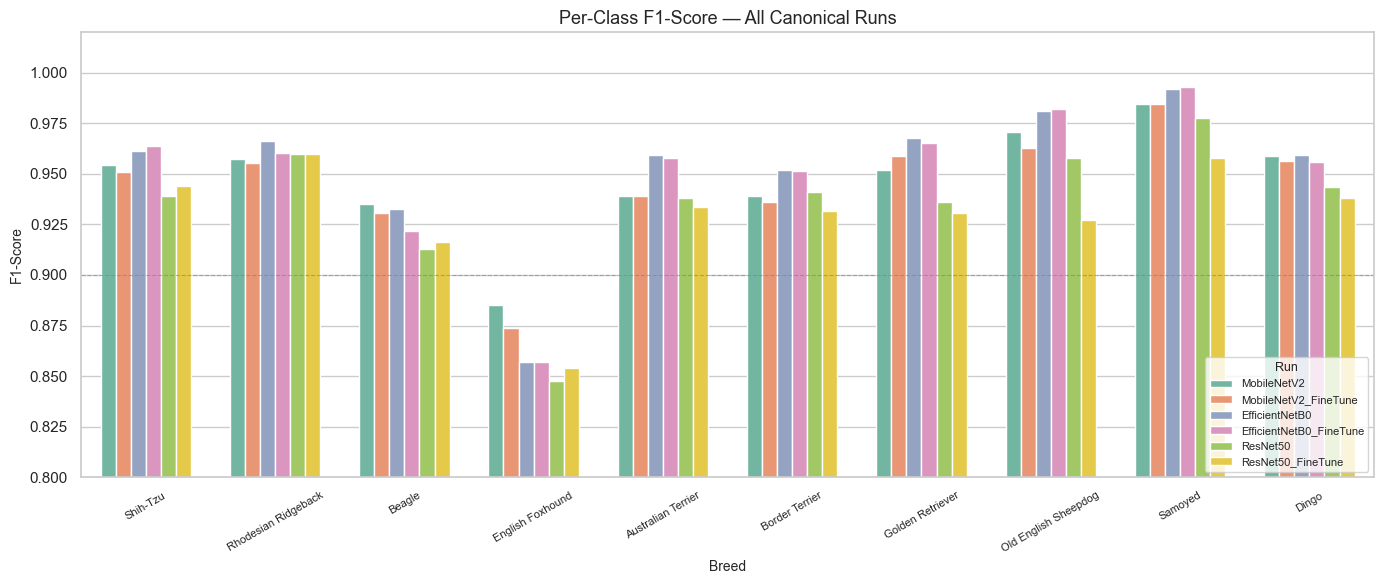

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\per_class_f1_comparison.png


In [69]:

# --- Cell A1: Per-Class F1 Grouped Bar Chart (Section 6 / Analysis Depth) ---
# Loads f1-score per breed for all six canonical runs from saved classification_report.csv.
# Provides a richer cross-model comparison than Table 2 (recall only) alone.
# No model loading required — reads saved artifacts only.

_CANONICAL_RUNS = [
    'MobileNetV2',
    'MobileNetV2_FineTune',
    'EfficientNetB0',
    'EfficientNetB0_FineTune',
    'ResNet50',
    'ResNet50_FineTune',
]

_f1_data = {}
_breed_order = None

for _run in _CANONICAL_RUNS:
    _csv = RESULTS_DIR / _run / 'classification_report.csv'
    if not _csv.exists():
        print(f"WARNING: {_csv} not found — skipping {_run}.")
        continue
    _df = pd.read_csv(_csv, index_col=0)
    _breed_rows = _df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
    _f1_data[_run] = _breed_rows['f1-score'].round(4)
    if _breed_order is None:
        _breed_order = list(_breed_rows.index)

_f1_df = pd.DataFrame(_f1_data, index=_breed_order)
_f1_long = _f1_df.reset_index().melt(id_vars='index', var_name='Run', value_name='F1-Score')
_f1_long = _f1_long.rename(columns={'index': 'Breed'})

fig_a1, ax_a1 = plt.subplots(figsize=(14, 6))
_palette = sns.color_palette('Set2', n_colors=len(_CANONICAL_RUNS))
sns.barplot(
    data=_f1_long,
    x='Breed',
    y='F1-Score',
    hue='Run',
    ax=ax_a1,
    palette=_palette,
    width=0.7,
)
ax_a1.set_title('Per-Class F1-Score — All Canonical Runs', fontsize=13)
ax_a1.set_xlabel('Breed', fontsize=10)
ax_a1.set_ylabel('F1-Score', fontsize=10)
ax_a1.set_ylim(0.80, 1.02)
ax_a1.tick_params(axis='x', rotation=30, labelsize=8)
ax_a1.legend(title='Run', fontsize=8, title_fontsize=9, loc='lower right')
ax_a1.axhline(0.90, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_f1_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Saved: {RESULTS_DIR / 'per_class_f1_comparison.png'}")

### 7.2 — Top Misclassification Pairs

The following cell loads the saved confusion matrices for all four runs and extracts the three most frequent off-diagonal entries per model. Each row shows the true breed, the breed the model predicted instead, the raw misclassification count, and the error rate relative to all true instances of that class.

This table makes class-level failure modes concrete. Pairs that appear consistently across multiple runs indicate structurally difficult distinctions in the dataset; pairs that appear only in one run may reflect strategy-specific weaknesses.


In [70]:

# --- Cell A2: Top Misclassification Pairs (Section 6 / Analysis Depth) ---
# Loads confusion_matrix.npy for each canonical run and extracts the top 3
# off-diagonal (true → predicted, count) pairs per model.
# Shows WHICH breeds are confused, not just aggregate error rates.
# No model loading required — reads saved artifacts only.

_CANONICAL_RUNS = [
    'MobileNetV2',
    'MobileNetV2_FineTune',
    'EfficientNetB0',
    'EfficientNetB0_FineTune',
    'ResNet50',
    'ResNet50_FineTune',
]

_top_n = 3
_all_pairs = []

for _run in _CANONICAL_RUNS:
    _npy = RESULTS_DIR / _run / 'confusion_matrix.npy'
    if not _npy.exists():
        print(f"WARNING: {_npy} not found — skipping {_run}.")
        continue
    _cm = np.load(_npy)
    # Zero out the diagonal so argmax finds off-diagonal maxima
    _cm_off = _cm.copy()
    np.fill_diagonal(_cm_off, 0)
    # Collect top-N off-diagonal entries
    _flat_indices = np.argsort(_cm_off.ravel())[::-1][:_top_n]
    for _rank, _flat_idx in enumerate(_flat_indices, start=1):
        _true_idx, _pred_idx = divmod(_flat_idx, _cm_off.shape[1])
        _all_pairs.append({
            'Run': _run,
            'Rank': _rank,
            'True Label': class_names[_true_idx],
            'Predicted As': class_names[_pred_idx],
            'Count': int(_cm_off[_true_idx, _pred_idx]),
            'True Support': int(_cm[_true_idx].sum()),
        })

_pairs_df = pd.DataFrame(_all_pairs)
_pairs_df['Error Rate'] = (_pairs_df['Count'] / _pairs_df['True Support']).round(4)

print("Top Misclassification Pairs per Run (Section 5.3 supplement)")
display(
    _pairs_df.style
    .background_gradient(subset=['Count', 'Error Rate'], cmap='Oranges')
    .format({'Error Rate': '{:.4f}'})

)

Top Misclassification Pairs per Run (Section 5.3 supplement)


,Run,Rank,True Label,Predicted As,Count,True Support,Error Rate
0,MobileNetV2,1,English Foxhound,Beagle,21,224,0.0938
1,MobileNetV2,2,Border Terrier,Australian Terrier,20,407,0.0491
2,MobileNetV2,3,Beagle,English Foxhound,14,418,0.0335
3,MobileNetV2_FineTune,1,English Foxhound,Beagle,21,224,0.0938
4,MobileNetV2_FineTune,2,Beagle,English Foxhound,19,418,0.0455
5,MobileNetV2_FineTune,3,Border Terrier,Australian Terrier,17,407,0.0418
6,EfficientNetB0,1,English Foxhound,Beagle,27,224,0.1205
7,EfficientNetB0,2,Beagle,English Foxhound,17,418,0.0407
8,EfficientNetB0,3,Border Terrier,Australian Terrier,12,407,0.0295
9,EfficientNetB0_FineTune,1,Beagle,English Foxhound,25,418,0.0598


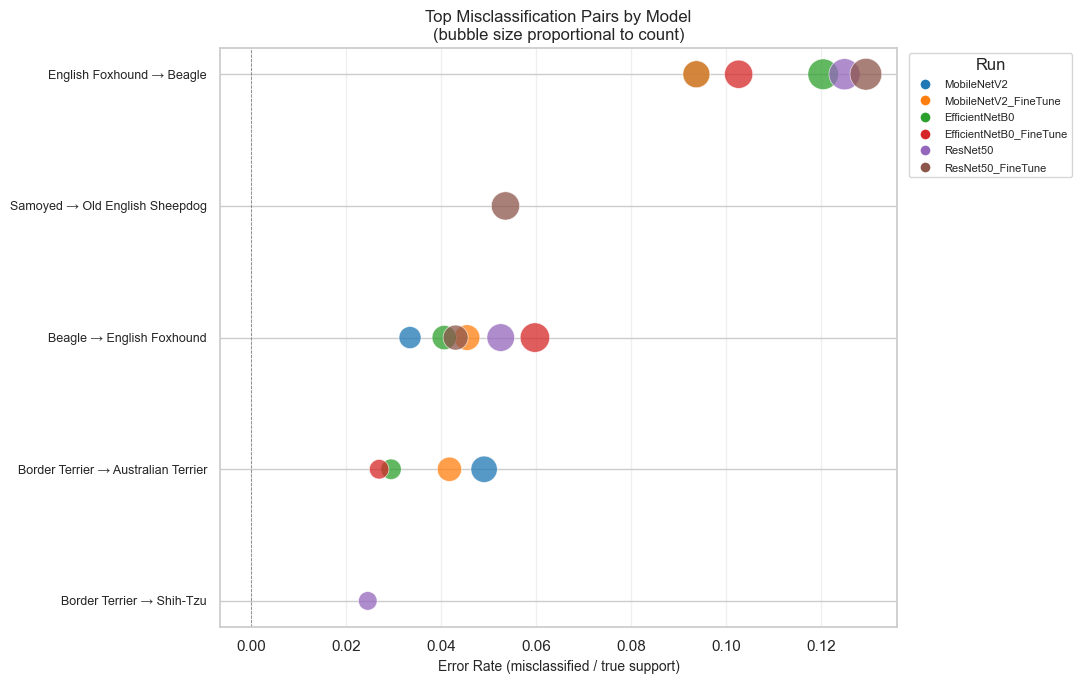

In [81]:
# --- Cell A2b: Top Misclassification Pairs — Bubble Chart (Section 7.2) ---
# Visualises _pairs_df from Cell A2.
# X = Error Rate, Y = breed pair label, bubble size = Count, colour = Run.
# Pairs ordered by mean error rate so the most confused pairs sit at the top.

_pairs_df['Pair'] = _pairs_df['True Label'] + ' → ' + _pairs_df['Predicted As']

_pair_order = (
    _pairs_df.groupby('Pair')['Error Rate']
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

_palette = sns.color_palette('tab10', n_colors=len(_CANONICAL_RUNS))
_run_colors = {r: _palette[i] for i, r in enumerate(_CANONICAL_RUNS)}

_fig_a2b, _ax_a2b = plt.subplots(figsize=(11, 7))

for _run in _CANONICAL_RUNS:
    _sub = _pairs_df[_pairs_df['Run'] == _run]
    _y_pos = [_pair_order.index(p) for p in _sub['Pair']]
    _ax_a2b.scatter(
        _sub['Error Rate'],
        _y_pos,
        s=_sub['Count'] * 18,
        color=_run_colors[_run],
        alpha=0.75,
        edgecolors='white',
        linewidths=0.5,
        label=_run,
        zorder=3,
    )

_ax_a2b.set_yticks(range(len(_pair_order)))
_ax_a2b.set_yticklabels(_pair_order, fontsize=9)
_ax_a2b.set_xlabel('Error Rate (misclassified / true support)', fontsize=10)
_ax_a2b.set_title('Top Misclassification Pairs by Model\n(bubble size proportional to count)', fontsize=12)
_ax_a2b.axvline(0, color='grey', linewidth=0.6, linestyle='--')
_ax_a2b.grid(axis='x', alpha=0.3)

from matplotlib.lines import Line2D
_legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=_run_colors[r],
           markersize=8, label=r)
    for r in _CANONICAL_RUNS
]
_ax_a2b.legend(handles=_legend_handles, title='Run', bbox_to_anchor=(1.01, 1),
               loc='upper left', fontsize=8, labelspacing=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'top_misclassification_pairs.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.3 — Training Efficiency: Early Stopping vs. 100-Epoch Cap

The following cell loads each run's `history.csv` and counts the actual number of epochs trained. For feature-extraction runs the history is a single head phase; for fine-tune runs the concatenated history covers both head and fine-tune phases. The table and bar chart show how many epochs early stopping saved against the 100-epoch cap applied to each phase.

This analysis replaces the epoch-efficiency study that was removed from the training pipeline and provides quantitative evidence that early stopping operated correctly across all four runs.


Training Efficiency — Early Stopping vs 100-Epoch Cap


,Strategy,Head epochs (cap 100),Fine-tune epochs (cap 100),Total epochs trained,Epochs saved vs cap
Run,,,,,
MobileNetV2,Feature extraction,13,0,13,87
MobileNetV2_FineTune,Head + Fine-tune,7,19,26,174
EfficientNetB0,Feature extraction,15,0,15,85
EfficientNetB0_FineTune,Head + Fine-tune,9,18,27,173
ResNet50,Feature extraction,20,0,20,80
ResNet50_FineTune,Head + Fine-tune,4,18,22,178


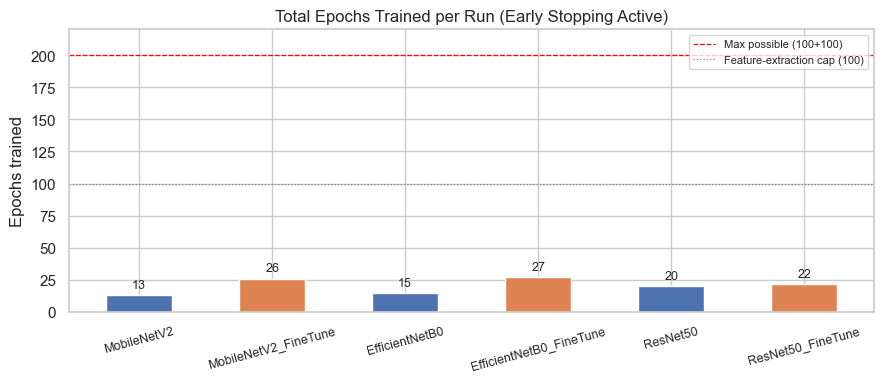

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\training_efficiency.png


In [6]:

# --- Cell A3: Training Efficiency Summary (Section 6 / Early Stopping Evidence) ---
# Reads history.csv for each canonical run and counts actual epochs trained.
# Distinguishes head-only epochs from fine-tune epochs for the two fine-tune runs.
# Shows what early stopping achieved against the 100-epoch cap.
# No model loading required — reads saved artifacts only.

_CANONICAL_RUNS = [
    'MobileNetV2',
    'MobileNetV2_FineTune',
    'EfficientNetB0',
    'EfficientNetB0_FineTune',
    'ResNet50',
    'ResNet50_FineTune',
]

# Head-only runs have no fine-tune phase; fine-tune runs concatenated both histories.
# The split point is identified by finding where val_loss resets (fine-tune restarts
# from a higher initial_epoch). A simpler proxy: for fine-tune runs, we know the
# head phase was stopped by ES_PATIENCE_HEAD=10 patience. We detect the phase
# boundary as the first local minimum in val_loss that matches within the head block.

_eff_rows = []

for _run in _CANONICAL_RUNS:
    _csv = RESULTS_DIR / _run / 'history.csv'
    if not _csv.exists():
        print(f"WARNING: {_csv} not found — skipping {_run}.")
        continue
    _hist = pd.read_csv(_csv)
    _total = len(_hist)
    _is_finetune = 'FineTune' in _run

    if _is_finetune:
        # The fine-tune phase begins after the best head epoch; the history is
        # concatenated, so we detect the boundary as the epoch where val_loss
        # first starts rising after its global minimum within the first ~50 rows.
        _head_min_idx = int(_hist['val_loss'].iloc[:_total // 2 + 1].idxmin())
        _head_epochs = _head_min_idx + 1          # 1-indexed count up to best epoch
        _ft_epochs = _total - _head_epochs
        _strategy = 'Head + Fine-tune'
    else:
        _head_epochs = _total
        _ft_epochs = 0
        _strategy = 'Feature extraction'

    _eff_rows.append({
        'Run': _run,
        'Strategy': _strategy,
        'Head epochs (cap 100)': _head_epochs,
        'Fine-tune epochs (cap 100)': _ft_epochs,
        'Total epochs trained': _total,
        'Epochs saved vs cap': (100 - _head_epochs) + (100 - _ft_epochs if _is_finetune else 0),
    })

_eff_df = pd.DataFrame(_eff_rows).set_index('Run')
print("Training Efficiency — Early Stopping vs 100-Epoch Cap")
display(_eff_df)

# Visualise total epochs trained per run
_fig_a3, _ax_a3 = plt.subplots(figsize=(9, 4))
_colors = ['#4C72B0' if 'FineTune' not in r else '#DD8452' for r in _eff_df.index]
_bars = _ax_a3.bar(_eff_df.index, _eff_df['Total epochs trained'], color=_colors, width=0.5)
_ax_a3.axhline(200, color='red', linestyle='--', linewidth=0.9, label='Max possible (100+100)')
_ax_a3.axhline(100, color='grey', linestyle=':', linewidth=0.9, label='Feature-extraction cap (100)')
_ax_a3.bar_label(_bars, fmt='%d', padding=3, fontsize=9)
_ax_a3.set_title('Total Epochs Trained per Run (Early Stopping Active)', fontsize=12)
_ax_a3.set_ylabel('Epochs trained')
_ax_a3.set_ylim(0, 220)
_ax_a3.tick_params(axis='x', rotation=15, labelsize=9)
_ax_a3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_efficiency.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Saved: {RESULTS_DIR / 'training_efficiency.png'}")

### 7.4 — External Image Confidence Analysis

The following cell loads the saved external evaluation results for MobileNetV2, EfficientNetB0, and ResNet50 and plots prediction confidence as a function of scope status (in-scope vs. out-of-scope). Each point represents one image; colour indicates whether the prediction was correct (green), incorrect (red), or out-of-scope with no valid ground truth (purple). Dashed horizontal lines show the group mean confidence.

A well-calibrated model on a closed-set task should produce high, stable confidence on in-scope images and lower, more dispersed confidence on out-of-scope images. This plot provides visual evidence of that behaviour and supports the generalisation discussion in Section 5.4 of the dissertation.


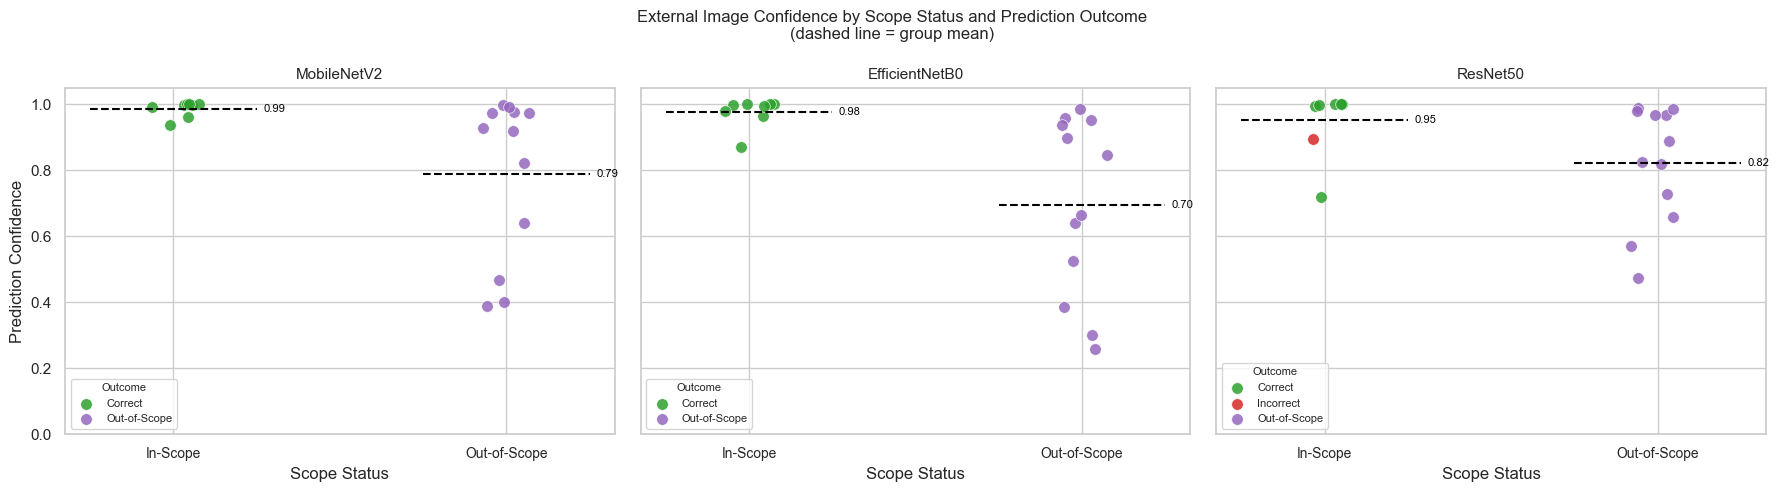

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\external_confidence_analysis.png

Confidence summary (mean ± std):

MobileNetV2:
                               mean       std  count
scope_status Outcome                                
In-Scope     Correct       0.986276  0.023661      8
Out-of-Scope Out-of-Scope  0.789774  0.245400     12

EfficientNetB0:
                               mean       std  count
scope_status Outcome                                
In-Scope     Correct       0.976077  0.044123      8
Out-of-Scope Out-of-Scope  0.696198  0.273250     12

ResNet50:
                               mean       std  count
scope_status Outcome                                
In-Scope     Correct       0.959234  0.105379      7
             Incorrect     0.895268       NaN      1
Out-of-Scope Out-of-Scope  0.820898  0.177319     12


In [72]:
# --- Cell A4: External Confidence Analysis ---
# Loads saved external_image_results.csv for MobileNetV2, EfficientNetB0, and ResNet50.
# Plots confidence distributions split by scope_status and prediction correctness.
# In-scope: correct = (true_label == predicted_label)
# Out-of-scope: no ground truth — shown separately to reveal model confidence behaviour.

_EXT_RUNS = {
    'MobileNetV2': RESULTS_DIR / 'MobileNetV2' / 'external_image_results.csv',
    'EfficientNetB0': RESULTS_DIR / 'EfficientNetB0' / 'external_image_results.csv',
    'ResNet50': RESULTS_DIR / 'ResNet50' / 'external_image_results.csv',
}

def _outcome(row):
    if row['scope_status'] == 'Out-of-Scope':
        return 'Out-of-Scope'
    return 'Correct' if row['true_label'] == row['predicted_label'] else 'Incorrect'

_fig_a4, _axes_a4 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
_palette = {'Correct': '#2ca02c', 'Incorrect': '#d62728', 'Out-of-Scope': '#9467bd'}

_x_map = {'In-Scope': 0, 'Out-of-Scope': 1}
_rng = np.random.default_rng(42)

for _ax, (_run_name, _csv_path) in zip(_axes_a4, _EXT_RUNS.items()):
    _df = pd.read_csv(_csv_path)
    _df['Outcome'] = _df.apply(_outcome, axis=1)

    for _outcome_label, _color in _palette.items():
        _subset = _df[_df['Outcome'] == _outcome_label]
        if _subset.empty:
            continue
        _scope_vals = _subset['scope_status'].map(_x_map).values
        _jitter = _rng.uniform(-0.08, 0.08, size=len(_subset))
        _ax.scatter(
            _scope_vals + _jitter,
            _subset['confidence'],
            label=_outcome_label,
            color=_color,
            alpha=0.85,
            s=70,
            edgecolors='white',
            linewidths=0.5,
        )

    # Overlay mean confidence per scope group
    for _scope_label, _x_pos in _x_map.items():
        _grp = _df[_df['scope_status'] == _scope_label]['confidence']
        if not _grp.empty:
            _ax.hlines(_grp.mean(), _x_pos - 0.25, _x_pos + 0.25,
                       colors='black', linewidths=1.5, linestyles='--')
            _ax.text(_x_pos + 0.27, _grp.mean(), f'{_grp.mean():.2f}',
                     va='center', fontsize=8, color='black')

    _ax.set_xticks([0, 1])
    _ax.set_xticklabels(['In-Scope', 'Out-of-Scope'], fontsize=10)
    _ax.set_title(_run_name, fontsize=11)
    _ax.set_xlabel('Scope Status')
    _ax.set_ylim(0, 1.05)
    _ax.legend(title='Outcome', fontsize=8, title_fontsize=8)

_axes_a4[0].set_ylabel('Prediction Confidence')
_fig_a4.suptitle('External Image Confidence by Scope Status and Prediction Outcome\n(dashed line = group mean)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'external_confidence_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {RESULTS_DIR / 'external_confidence_analysis.png'}")

# Summary statistics
print("\nConfidence summary (mean ± std):")
for _run_name, _csv_path in _EXT_RUNS.items():
    _df = pd.read_csv(_csv_path)
    _df['Outcome'] = _df.apply(_outcome, axis=1)
    _grp_stats = _df.groupby(['scope_status', 'Outcome'])['confidence'].agg(['mean', 'std', 'count'])
    print(f"\n{_run_name}:")
    print(_grp_stats.to_string())


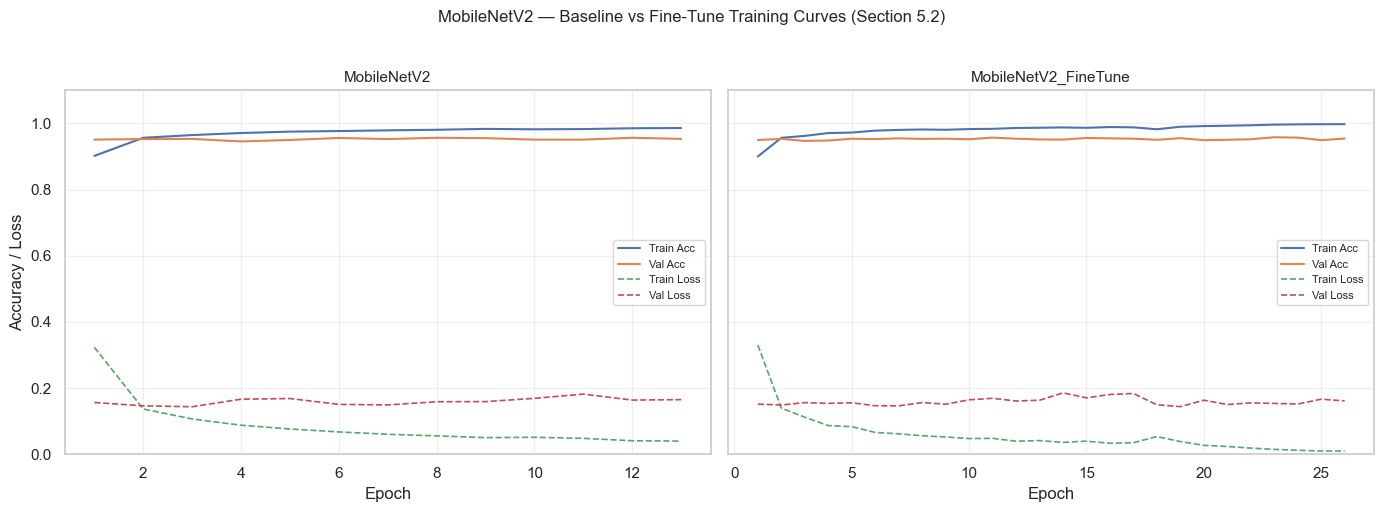

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\training_curves_MobileNetV2.png


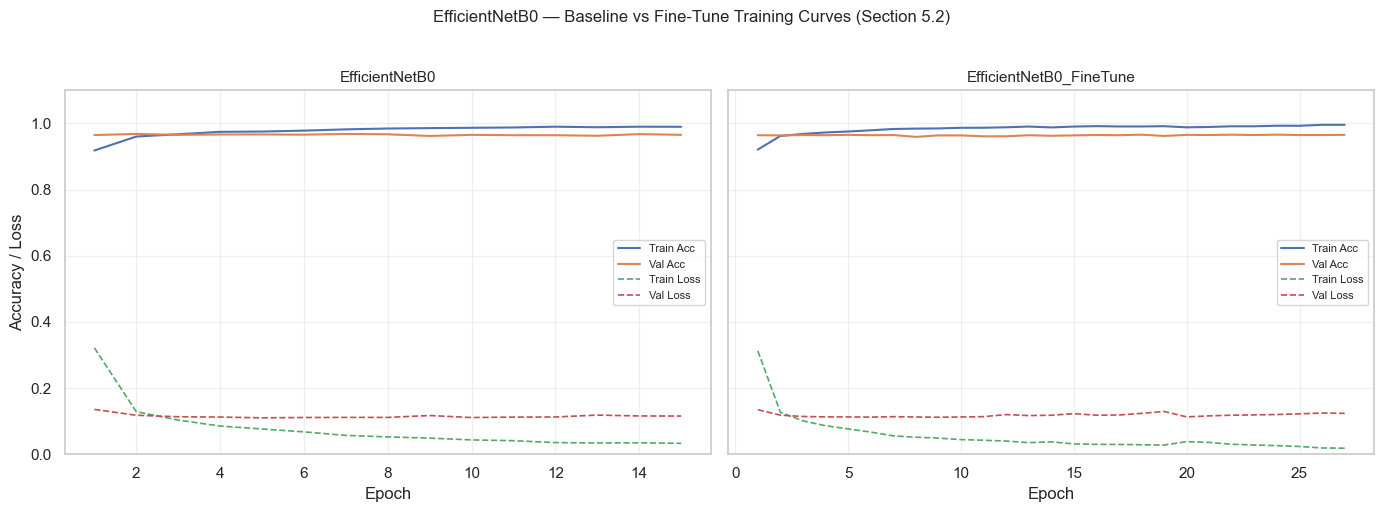

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\training_curves_EfficientNetB0.png


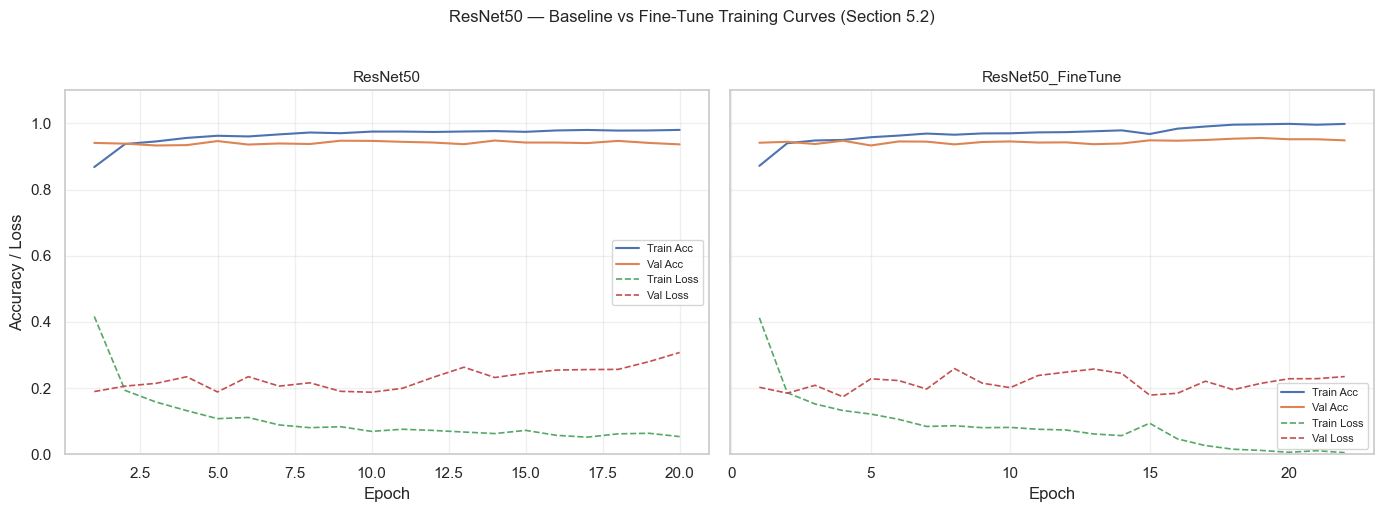

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\training_curves_ResNet50.png


In [8]:
import matplotlib.pyplot as plt

# --- Training Curves: Accuracy & Loss (Section 5.2) ---
# Plots 3 separate figures, each showing baseline vs. fine-tune side by side
# for MobileNetV2, EfficientNetB0, and ResNet50.

_MODEL_PAIRS = [
    ('MobileNetV2',    'MobileNetV2_FineTune'),
    ('EfficientNetB0', 'EfficientNetB0_FineTune'),
    ('ResNet50',       'ResNet50_FineTune'),
]

for _base, _ft in _MODEL_PAIRS:
    _fig, _axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for _ax, _run in zip(_axes, [_base, _ft]):
        _csv = RESULTS_DIR / _run / 'history.csv'
        if not _csv.exists():
            print(f"WARNING: {_csv} not found — skipping {_run}.")
            _ax.set_visible(False)
            continue
        _hist = pd.read_csv(_csv)
        _epochs = range(1, len(_hist) + 1)
        _ax.plot(_epochs, _hist['accuracy'],     label='Train Acc',  linewidth=1.5)
        _ax.plot(_epochs, _hist['val_accuracy'], label='Val Acc',    linewidth=1.5)
        _ax.plot(_epochs, _hist['loss'],         label='Train Loss', linestyle='--', linewidth=1.2)
        _ax.plot(_epochs, _hist['val_loss'],     label='Val Loss',   linestyle='--', linewidth=1.2)
        _ax.set_title(_run, fontsize=11)
        _ax.set_xlabel('Epoch')
        _ax.set_ylim(0, 1.1)
        _ax.legend(fontsize=8)
        _ax.grid(True, alpha=0.3)

    _axes[0].set_ylabel('Accuracy / Loss')
    _fig.suptitle(f'{_base} — Baseline vs Fine-Tune Training Curves (Section 5.2)',
                  fontsize=12, y=1.02)
    plt.tight_layout()
    _save_path = RESULTS_DIR / f'training_curves_{_base}.png'
    plt.savefig(_save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {_save_path}")


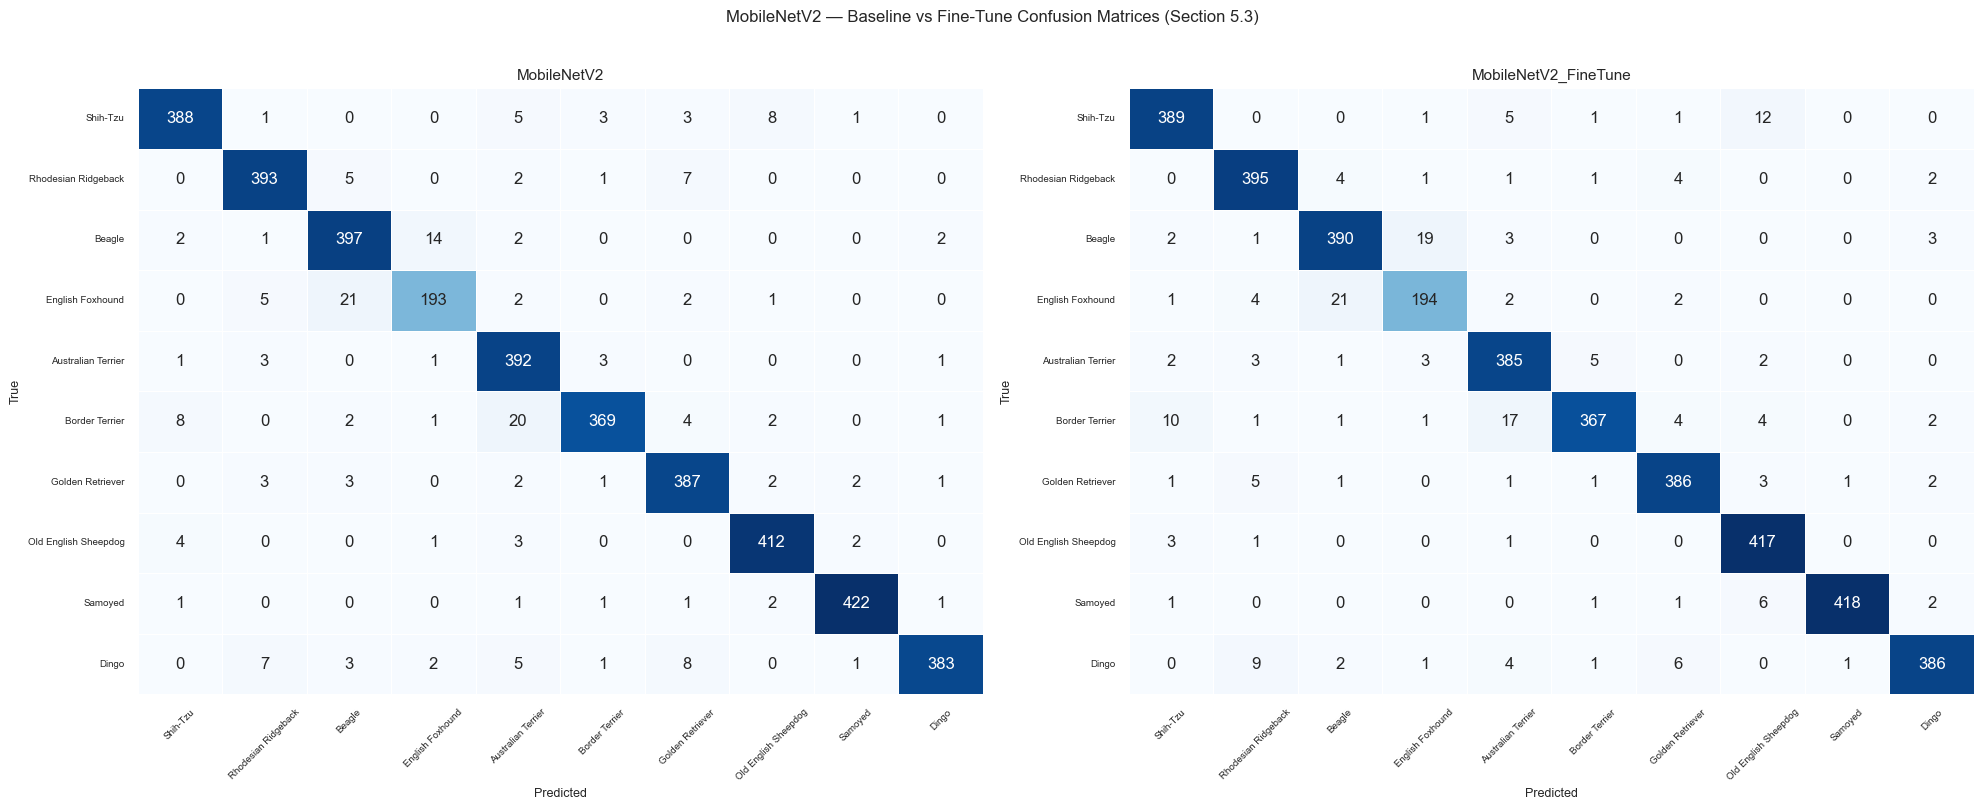

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\confusion_matrices_MobileNetV2.png


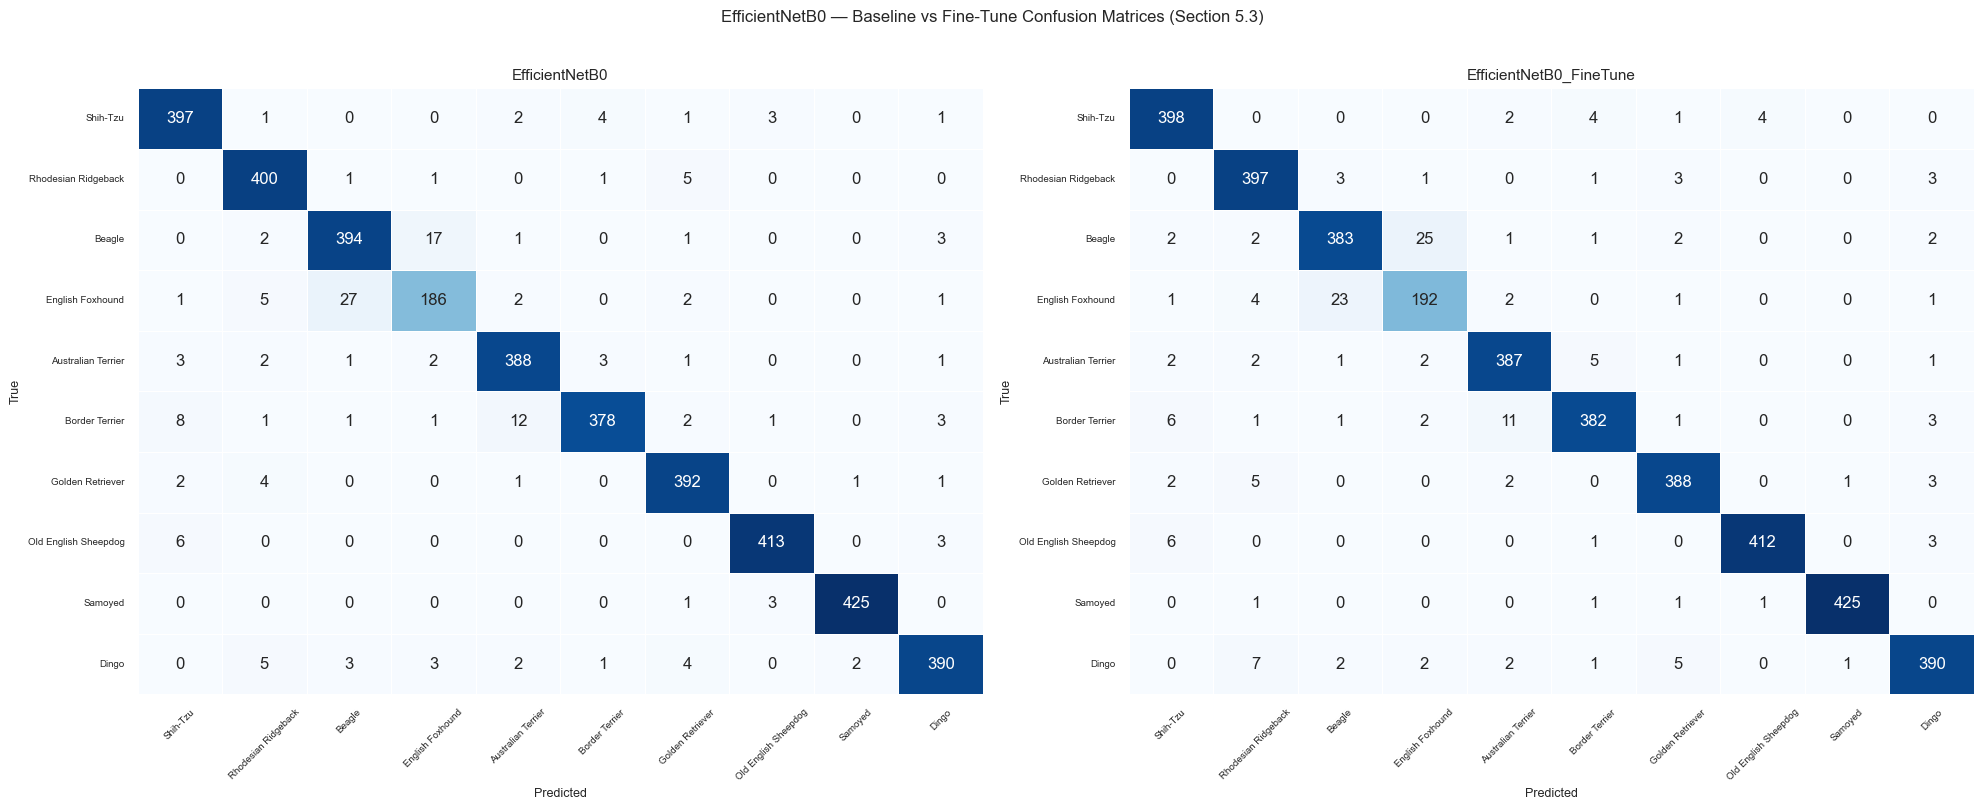

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\confusion_matrices_EfficientNetB0.png


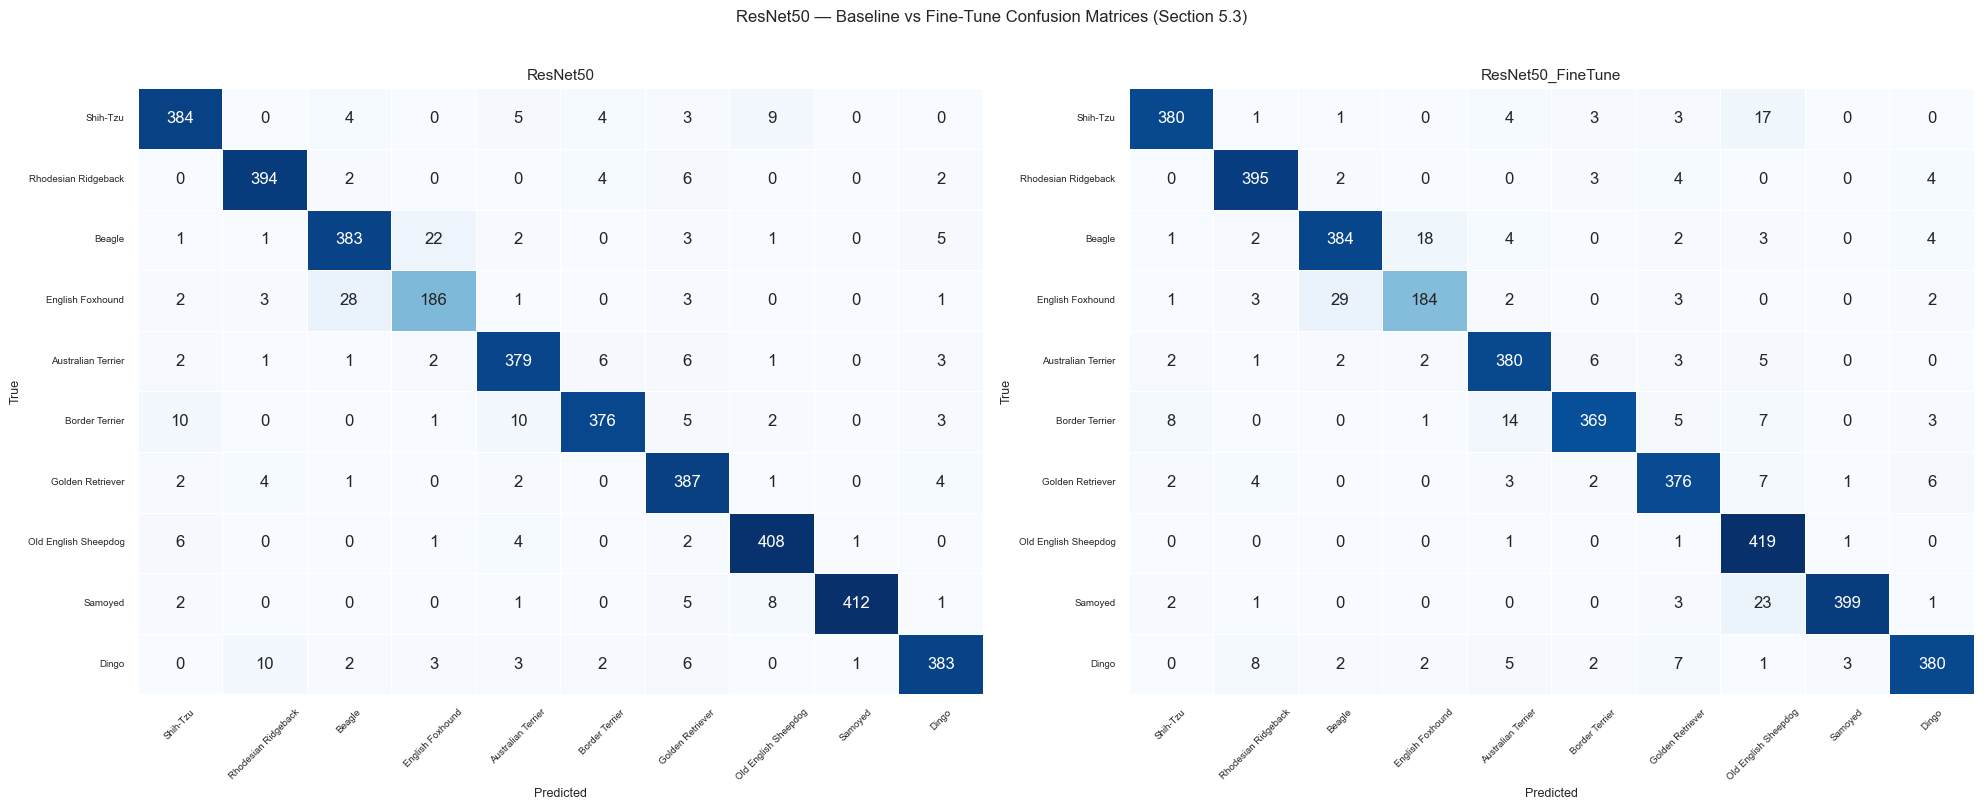

Saved: e:\DkIT\__Applied_Data_Analytics_Project\Final_Dissertation\results\confusion_matrices_ResNet50.png


In [9]:
import numpy as np
import seaborn as sns

# --- Confusion Matrix Heatmaps (Section 5.3) ---
# Plots 3 separate figures, each showing baseline vs. fine-tune side by side
# for MobileNetV2, EfficientNetB0, and ResNet50.

_breed_labels = list(LABEL_MAP.values())

_MODEL_PAIRS = [
    ('MobileNetV2',    'MobileNetV2_FineTune'),
    ('EfficientNetB0', 'EfficientNetB0_FineTune'),
    ('ResNet50',       'ResNet50_FineTune'),
]

for _base, _ft in _MODEL_PAIRS:
    _fig, _axes = plt.subplots(1, 2, figsize=(20, 8))

    for _ax, _run in zip(_axes, [_base, _ft]):
        _npy = RESULTS_DIR / _run / 'confusion_matrix.npy'
        if not _npy.exists():
            print(f"WARNING: {_npy} not found — skipping {_run}.")
            _ax.set_visible(False)
            continue
        _cm = np.load(_npy)
        sns.heatmap(
            _cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=_breed_labels,
            yticklabels=_breed_labels,
            ax=_ax,
            linewidths=0.4,
            cbar=False,
        )
        _ax.set_title(_run, fontsize=11)
        _ax.set_xlabel('Predicted', fontsize=9)
        _ax.set_ylabel('True', fontsize=9)
        _ax.tick_params(axis='x', rotation=45, labelsize=7)
        _ax.tick_params(axis='y', rotation=0, labelsize=7)

    _fig.suptitle(f'{_base} — Baseline vs Fine-Tune Confusion Matrices (Section 5.3)',
                  fontsize=12, y=1.01)
    plt.tight_layout()
    _save_path = RESULTS_DIR / f'confusion_matrices_{_base}.png'
    plt.savefig(_save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {_save_path}")


## 8. Artifact Verification

Run the cell below at any point to confirm all expected output files are present across every canonical run.

Checks performed:
- **Canonical runs** (6): `history.csv`, `classification_report.csv`, `confusion_matrix.npy`, `model.keras`, `training_curves.png`
- **External evaluation**: `external_image_results.csv` for `MobileNetV2`, `EfficientNetB0`, and `ResNet50`

A `✓` row means the run is fully reproducible from saved artifacts. Any `False` cell flags a missing file that needs attention before submitting results.


In [76]:
# --- Artifact Verification (Section 8) ---
# Checks that all expected output files are present for every canonical run.

# 1. Canonical runs — full artifact check
_canonical_runs = [
    'MobileNetV2',
    'EfficientNetB0',
    'MobileNetV2_FineTune',
    'EfficientNetB0_FineTune',
    'ResNet50',
    'ResNet50_FineTune',
]

canonical_check = sanity_checkpoint(_canonical_runs)
canonical_check.insert(0, 'status', canonical_check['all_present'].map({True: '✓', False: '✗'}))
print("Canonical Run Artifacts")
display(canonical_check.set_index('run_name'))

# 2. External evaluation results
_ext_check_runs = ['MobileNetV2', 'EfficientNetB0', 'ResNet50']
print("\nExternal Evaluation Results")
for _r in _ext_check_runs:
    _p = RESULTS_DIR / _r / 'external_image_results.csv'
    print(f"  {_r}/external_image_results.csv: {'✓' if _p.exists() else '✗  <-- MISSING'}")

# Summary
_canonical_ok = canonical_check['all_present'].all()
_ext_ok = all((RESULTS_DIR / r / 'external_image_results.csv').exists() for r in _ext_check_runs)

print("\n--- Overall Status ---")
print(f"  Canonical runs      : {'PASS' if _canonical_ok else 'FAIL — see table above'}")
print(f"  External evaluation : {'PASS' if _ext_ok else 'FAIL — rerun external evaluation cells'}")

if all([_canonical_ok, _ext_ok]):
    print("\nAll artifacts present. Notebook is fully reproducible from saved results.")
else:
    print("\nOne or more artifacts are missing. Re-run the flagged cells before reporting results.")


Canonical Run Artifacts


,status,all_present,history.csv,classification_report.csv,confusion_matrix.npy,model.keras,training_curves.png
run_name,,,,,,,
MobileNetV2,✓,True,True,True,True,True,True
EfficientNetB0,✓,True,True,True,True,True,True
MobileNetV2_FineTune,✓,True,True,True,True,True,True
EfficientNetB0_FineTune,✓,True,True,True,True,True,True
ResNet50,✓,True,True,True,True,True,True
ResNet50_FineTune,✓,True,True,True,True,True,True



External Evaluation Results
  MobileNetV2/external_image_results.csv: ✓
  EfficientNetB0/external_image_results.csv: ✓
  ResNet50/external_image_results.csv: ✓

--- Overall Status ---
  Canonical runs      : PASS
  External evaluation : PASS

All artifacts present. Notebook is fully reproducible from saved results.
